## Aggergation & Temporal_Preprocessing

In [ ]:
import pandas as pd
import numpy as np
import os
from typing import List, Dict, Tuple
from pathlib import Path

# Set random seed for reproducibility
np.random.seed(42)

# ================================================================
# 1. Load & Filter
# ================================================================
def load_and_filter_data(file_path: str, min_records_per_user: int = 1000) -> pd.DataFrame:
    print(f"Loading data from: {file_path}")
    try:
        df = pd.read_csv(file_path, parse_dates=['datetime'])
    except Exception as e:
        print(f"Error loading file: {e}")
        return pd.DataFrame()

    df = df[df['diff'] >= 0].copy()

    counts = df['user key'].value_counts()
    keep_users = counts[counts >= min_records_per_user].index
    df = df[df['user key'].isin(keep_users)].copy()

    print(f"Total users after filtering (>= {min_records_per_user} records): {len(keep_users)}")
    if not df.empty:
        print(f"Full dataset date range: {df['datetime'].min()} -> {df['datetime'].max()}")
    return df

# ================================================================
# 2. Temporal Splits with Validation
# ================================================================
def create_temporal_splits_simple(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Temporal splits:
      - Train: 2015-01-01 -> 2016-09-30
      - Val:   2016-10-01 -> 2016-12-31
      - Test:  2017-01-01 onwards
    """
    train_end = pd.Timestamp("2016-09-30 23:59:59")
    val_end = pd.Timestamp("2016-12-31 23:59:59")

    train_df = df[df["datetime"] <= train_end].copy()
    val_df = df[(df["datetime"] > train_end) & (df["datetime"] <= val_end)].copy()
    test_df = df[df["datetime"] > val_end].copy()

    print("\n" + "="*80)
    print("TEMPORAL SPLIT VALIDATION")
    print(f"Train: {len(train_df):,} records")
    print(f"Val:   {len(val_df):,} records")
    print(f"Test:  {len(test_df):,} records")
    print("="*80)
    
    return train_df, val_df, test_df

# ================================================================
# 3. Feature Engineering
# ================================================================
def add_lag_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # Lags based on the CLIPPED demand (context), but raw demand remains col 0
    df["lag_1h"] = df["total_demand_clipped"].shift(1)
    df["lag_2h"] = df["total_demand_clipped"].shift(2)
    df["lag_3h"] = df["total_demand_clipped"].shift(3)
    df["lag_6h"] = df["total_demand_clipped"].shift(6)
    df["lag_12h"] = df["total_demand_clipped"].shift(12)
    df["lag_24h"] = df["total_demand_clipped"].shift(24)
    df["lag_48h"] = df["total_demand_clipped"].shift(48)
    df["lag_168h"] = df["total_demand_clipped"].shift(168)

    df["rolling_mean_6h"] = df["total_demand_clipped"].rolling(6, min_periods=1).mean()
    df["rolling_mean_12h"] = df["total_demand_clipped"].rolling(12, min_periods=1).mean()
    df["rolling_mean_24h"] = df["total_demand_clipped"].rolling(24, min_periods=1).mean()
    df["rolling_std_6h"] = df["total_demand_clipped"].rolling(6, min_periods=1).std()
    df["rolling_std_24h"] = df["total_demand_clipped"].rolling(24, min_periods=1).std()

    df["hourly_change"] = df["total_demand_clipped"].diff()
    df["daily_change"] = df["total_demand_clipped"].diff(24)
    df["weekly_change"] = df["total_demand_clipped"].diff(168)

    df = df.fillna(0)
    return df

def add_context_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["hour"] = df.index.hour
    df["date"] = df.index.date

    daily_stats = df.groupby("date")["total_demand_clipped"].agg(["sum", "max", "mean", "std"])
    daily_stats.columns = ["daily_sum", "daily_max", "daily_mean", "daily_std"]
    df["cumsum_day"] = df.groupby("date")["total_demand_clipped"].cumsum()
    df = df.join(daily_stats, on="date")

    df["pct_of_daily"] = df["cumsum_day"] / (df["daily_sum"] + 1e-7)
    df["is_peak_hour"] = (df["total_demand_clipped"] > 0.9 * df["daily_max"]).astype(int)
    df["relative_to_peak"] = df["total_demand_clipped"] / (df["daily_max"] + 1e-7)
    df["hours_from_noon"] = np.abs(df["hour"] - 12)
    df["hours_from_midnight"] = np.minimum(df["hour"], 24 - df["hour"])

    df = df.drop(["hour", "date", "daily_sum", "daily_max", "daily_mean", "daily_std"], axis=1)
    return df

def add_stability_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["cv_6h"] = df["rolling_std_6h"] / (df["rolling_mean_6h"] + 1e-7)
    df["cv_24h"] = df["rolling_std_24h"] / (df["rolling_mean_24h"] + 1e-7)
    df["pattern_stability"] = 1 / (1 + df["rolling_std_24h"])
    df["deviation_6h"] = (df["total_demand_clipped"] - df["rolling_mean_6h"]) / (df["rolling_std_6h"] + 1e-7)
    df["deviation_24h"] = (df["total_demand_clipped"] - df["rolling_mean_24h"]) / (df["rolling_std_24h"] + 1e-7)
    df = df.replace([np.inf, -np.inf], 0)
    return df

def add_time_features_enhanced(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["hour"] = df.index.hour
    df["day_of_week"] = df.index.dayofweek
    df["month"] = df.index.month
    df["day_of_month"] = df.index.day
    df["week_of_year"] = df.index.isocalendar().week
    df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
    df["dom_sin"] = np.sin(2 * np.pi * df["day_of_month"] / 30)
    df["dom_cos"] = np.cos(2 * np.pi * df["day_of_month"] / 30)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df = pd.concat([df,
                    pd.get_dummies(df["day_of_week"], prefix="day_of_week", drop_first=False).reindex(columns=[f"day_of_week_{i}" for i in range(7)], fill_value=0),
                    pd.get_dummies(df["month"], prefix="month", drop_first=False).reindex(columns=[f"month_{i}" for i in range(1,13)], fill_value=0)], axis=1)

    drop_cols = ["hour", "day_of_week", "month", "day_of_month", "week_of_year"]
    df = df.drop(drop_cols, axis=1)
    return df

# ================================================================
# 4. Aggregation
# ================================================================
def aggregate_users_demand(df: pd.DataFrame, selected_users: List) -> pd.DataFrame:
    user_df = df[df["user key"].isin(selected_users)].copy()
    user_df["dt"] = user_df["datetime"].dt.floor("h")
    per_user_hour = user_df.groupby(["dt", "user key"], as_index=False)["diff"].sum()

    # SCENARIO B LOGIC: 'total_demand' (Raw) is created first
    agg = per_user_hour.groupby("dt").agg(total_demand=("diff", "sum"),
                                          active_users=("user key", "nunique")).sort_index()

    full_index = pd.date_range(start=agg.index.min(), end=agg.index.max(), freq="h")
    agg = agg.reindex(full_index).fillna({"total_demand": 0, "active_users": 0})

    # Outlier clipping is added as a NEW column
    q_low, q_high = agg["total_demand"].quantile([0.001, 0.999])
    agg["total_demand_clipped"] = agg["total_demand"].clip(lower=q_low, upper=q_high)

    agg = add_time_features_enhanced(agg)
    agg = add_lag_features(agg)
    agg = add_context_features(agg)
    agg = add_stability_features(agg)

    agg["num_users"] = len(selected_users)
    agg["user_list"] = str(selected_users)
    return agg

# ================================================================
# 5. Fixed User Selection + Normalization
# ================================================================
def select_random_users(available_users: List, level: int, trial: int, base_seed: int = 42) -> List:
    """Select different users for each trial using deterministic randomization"""
    trial_seed = base_seed + (level * 1000) + trial
    np.random.seed(trial_seed)
    
    if level >= len(available_users):
        selected = available_users.copy()
    else:
        selected = np.random.choice(available_users, size=level, replace=False).tolist()
    
    # print(f"    Trial {trial+1}: Selected users (seed={trial_seed})")
    return selected

def compute_global_normalization_params(train_datasets: Dict) -> Tuple[List[str], Dict]:
    """Compute normalization parameters from raw (pre-normalized) training data"""
    print("\nComputing global normalization parameters from training data...")

    first_key = next(iter(train_datasets))
    feature_columns = [col for col in train_datasets[first_key]["data"].columns 
                       if col not in ["user_list"]]

    all_train_data = []
    for dataset in train_datasets.values():
        all_train_data.append(dataset["data"][feature_columns])

    combined_train = pd.concat(all_train_data, ignore_index=True)

    norm_params = {}
    for col in feature_columns:
        min_val = float(combined_train[col].min())
        max_val = float(combined_train[col].max())
        norm_params[col] = {"min": min_val, "max": max_val}

    print(f"  Global normalization computed for {len(feature_columns)} features")
    return feature_columns, norm_params

def save_datasets_to_files(all_datasets: Dict, save_dir: str, split_name: str,
                           feature_columns: List[str], global_norm_params: Dict = None):
    """Save datasets with per-trial normalization"""
    os.makedirs(save_dir, exist_ok=True)

    for dataset_key, dataset in all_datasets.items():
        agg_data = dataset["data"]

        # Ensure same feature set
        agg_data_subset = agg_data.copy()
        for col in feature_columns:
            if col not in agg_data_subset.columns:
                agg_data_subset[col] = 0.0
        agg_data_subset = agg_data_subset[feature_columns].astype(float)

        # Compute per-trial norm_params
        trial_norm_params = {}
        for col in feature_columns:
            min_val = float(agg_data_subset[col].min())
            max_val = float(agg_data_subset[col].max())
            trial_norm_params[col] = {"min": min_val, "max": max_val}

        # Normalize
        normed_data = agg_data_subset.copy()
        for col in feature_columns:
            min_val = trial_norm_params[col]["min"]
            max_val = trial_norm_params[col]["max"]
            if max_val - min_val > 1e-7:
                normed_data[col] = (normed_data[col] - min_val) / (max_val - min_val)
            else:
                normed_data[col] = 0.0

        # Reshape into windows
        num_features = len(feature_columns)
        num_records = len(normed_data)
        num_windows = num_records // 24
        dataX = normed_data.values[:num_windows*24].reshape(num_windows, 24, num_features)

        # Save
        save_path = os.path.join(save_dir, f"{split_name}_preprocessed_{dataset_key}.npz")
        np.savez(save_path,
                 data=dataX,
                 norm_params=trial_norm_params,
                 feature_names=feature_columns,
                 index=agg_data.index[:num_windows*24].astype(str).to_numpy(),
                 metadata={"aggregation_level": dataset["level"],
                           "trial": dataset["trial"],
                           "total_features": num_features,
                           "num_windows": num_windows,
                           "split": split_name,
                           "users": dataset["users"],
                           "date_range": f"{agg_data.index.min()} to {agg_data.index.max()}"})
        
        # print(f"    Saved: {save_path} | Shape={dataX.shape}")

def create_multiple_aggregation_datasets(df: pd.DataFrame, aggregation_levels: List[int],
                                      n_trials: int = 10, split_name: str = "") -> Dict:
    print(f"\n=== Creating {split_name.upper()} datasets ===")
    
    available_users = df["user key"].value_counts().index.tolist()
    
    all_datasets = {}
    
    for level in aggregation_levels:
        for trial in range(n_trials):
            selected_users = select_random_users(available_users, level, trial)
            agg_data = aggregate_users_demand(df, selected_users)
            
            dataset_key = f"level_{level}_trial_{trial+1}"
            all_datasets[dataset_key] = {
                "data": agg_data, 
                "level": level, 
                "users": selected_users, 
                "trial": trial+1
            }
    
    print(f"Created {len(all_datasets)} {split_name} datasets")
    return all_datasets

def create_temporal_datasets_for_level(df, selected_level, n_trials=10, save_dir=None):
    print("="*80)
    print(f"CREATING TEMPORAL DATASETS FOR LEVEL {selected_level}")
    print("="*80)
    
    train_df, val_df, test_df = create_temporal_splits_simple(df)

    train_datasets = create_multiple_aggregation_datasets(train_df, [selected_level], n_trials, "train")
    val_datasets = create_multiple_aggregation_datasets(val_df, [selected_level], n_trials, "val")  
    test_datasets = create_multiple_aggregation_datasets(test_df, [selected_level], n_trials, "test")

    feature_columns, norm_params = compute_global_normalization_params(train_datasets)

    if save_dir:
        print(f"\nSaving datasets to {save_dir}...")
        save_datasets_to_files(train_datasets, os.path.join(save_dir, "train"), "train", feature_columns, norm_params)
        save_datasets_to_files(val_datasets, os.path.join(save_dir, "val"), "val", feature_columns, norm_params)
        save_datasets_to_files(test_datasets, os.path.join(save_dir, "test"), "test", feature_columns, norm_params)

    return train_datasets, val_datasets, test_datasets

def validate_dataset_files(save_dir: str, selected_level: int, n_trials: int):
    print("\n" + "="*80)
    print("DATASET VALIDATION")
    print("="*80)
    
    created_trials = 0
    for trial in range(n_trials):
        trial_file = os.path.join(save_dir, "train", f"train_preprocessed_level_{selected_level}_trial_{trial+1}.npz")
        if os.path.exists(trial_file):
            created_trials += 1
    
    print(f"  Expected trials: {n_trials}")
    print(f"  Created trials: {created_trials}")
    
    if created_trials == n_trials:
        print(f"\n✓ All validations passed")
        return True
    else:
        print(f"\n⚠️  Issues: Expected {n_trials} trials but found {created_trials}")
        return False

# ================================================================
# 8. Main Function
# ================================================================
def main_temporal_interactive():
    # --- UPDATED PATHS ---
    RAW_DATA_PATH = r"C:\Users\bin150\OneDrive - UBC\Desktop\Publication\WR2\cft-vae\data\Good_Data.csv"
    SAVE_BASE_DIR = r"C:\Users\bin150\OneDrive - UBC\Desktop\Publication\WR2\cft-vae\data"

    print("TEMPORAL DATA PROCESSING PIPELINE - SCENARIO B (Robustness)")
    print("="*80)
    
   
    df = load_and_filter_data(RAW_DATA_PATH, min_records_per_user=10000)
    
    if df.empty:
        print("Data load failed.")
        return

    all_levels = [1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 80, 100, 200, 250, 300, 350, 500, 700, 800, 1000]
    
    print(f"\nAvailable aggregation levels:")
    for i, level in enumerate(all_levels, 1):
        print(f"  {i:2d}. Level {level}")
    
    while True:
        try:
            level_choice = int(input(f"\nEnter the level number (1-{len(all_levels)}): "))
            if 1 <= level_choice <= len(all_levels):
                selected_level = all_levels[level_choice - 1]
                break
        except ValueError: pass
    
    while True:
        try:
            user_input = input("Enter number of trials (default 100): ").strip()
            if user_input == "":
                n_trials = 100
            else:
                n_trials = int(user_input)
            if n_trials > 0: break
        except ValueError: pass
    
    print(f"\nConfiguration:")
    print(f"  Selected level: {selected_level}")
    print(f"  Number of trials: {n_trials}")
    print(f"  Save directory: {SAVE_BASE_DIR}")

    train_datasets, val_datasets, test_datasets = create_temporal_datasets_for_level(
        df, selected_level, n_trials=n_trials, save_dir=SAVE_BASE_DIR
    )

    validation_passed = validate_dataset_files(SAVE_BASE_DIR, selected_level, n_trials)
    
    if validation_passed:
        print(f"\n🎯 Pipeline completed successfully!")
        print(f"   Files saved to: {SAVE_BASE_DIR}")

if __name__ == "__main__":
    main_temporal_interactive()

TEMPORAL DATA PROCESSING PIPELINE - SCENARIO B (Robustness)
Loading data from: C:\Users\bin150\OneDrive - UBC\Desktop\Publication\WR2\cft-vae\data\Good_Data.csv
Total users after filtering (>= 1000 records): 1064
Full dataset date range: 2015-01-01 02:00:06 -> 2017-05-19 23:59:59

Available aggregation levels:
   1. Level 1
   2. Level 5
   3. Level 10
   4. Level 15
   5. Level 20
   6. Level 25
   7. Level 30
   8. Level 35
   9. Level 40
  10. Level 45
  11. Level 50
  12. Level 55
  13. Level 60
  14. Level 65
  15. Level 70
  16. Level 80
  17. Level 100
  18. Level 200
  19. Level 250
  20. Level 300
  21. Level 350
  22. Level 500
  23. Level 700
  24. Level 800
  25. Level 1000



Enter the level number (1-25):  15
Enter number of trials (default 100):  100



Configuration:
  Selected level: 70
  Number of trials: 100
  Save directory: C:\Users\bin150\OneDrive - UBC\Desktop\Publication\WR2\cft-vae\data
CREATING TEMPORAL DATASETS FOR LEVEL 70

TEMPORAL SPLIT VALIDATION
Train: 11,155,559 records
Val:   1,727,370 records
Test:  2,609,915 records

=== Creating TRAIN datasets ===
Created 100 train datasets

=== Creating VAL datasets ===
Created 100 val datasets

=== Creating TEST datasets ===
Created 100 test datasets

Computing global normalization parameters from training data...
  Global normalization computed for 59 features

Saving datasets to C:\Users\bin150\OneDrive - UBC\Desktop\Publication\WR2\cft-vae\data...

DATASET VALIDATION
  Expected trials: 100
  Created trials: 100

✓ All validations passed

🎯 Pipeline completed successfully!
   Files saved to: C:\Users\bin150\OneDrive - UBC\Desktop\Publication\WR2\cft-vae\data


# Model definition

In [26]:
import numpy as np
import tensorflow as tf
import os
import time
import pandas as pd
from pathlib import Path
from tensorflow.keras import backend as K
from tensorflow.keras.layers import (
    Conv1D, Flatten, Dense, Conv1DTranspose, Reshape, Input, Layer, LSTM
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Mean

# Set random seeds for reproducibility
os.environ['TF_DETERMINISTIC_OPS'] = '1'
tf.keras.utils.set_random_seed(123)
tf.keras.backend.set_floatx('float32')

# -------------------------------------------------
# TimeVAE Model Definition (Complete with Synthetic Generation)
# -------------------------------------------------

class Sampling(Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

def temporal_consistency_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    diff_true = y_true[:, 1:] - y_true[:, :-1]
    diff_pred = y_pred[:, 1:] - y_pred[:, :-1]
    return tf.reduce_mean(tf.square(diff_true - diff_pred))

class BaseVariationalAutoencoder(Model):
    model_name = None
    def __init__(
        self,
        seq_len,
        feat_dim,
        cond_dim,
        latent_dim,
        reconstruction_wt=3.0,
        dtw_wt=1.0,
        beta=2.0,
        forecast_wt=1.0,
        batch_size=16,
        **kwargs,
    ):
        super(BaseVariationalAutoencoder, self).__init__(**kwargs)
        self.seq_len = seq_len
        self.feat_dim = feat_dim
        self.cond_dim = cond_dim
        self.latent_dim = latent_dim
        self.reconstruction_wt = reconstruction_wt
        self.dtw_wt = dtw_wt
        self.beta = beta
        self.forecast_wt = forecast_wt
        self.batch_size = batch_size

        # Metrics
        self.total_loss_tracker = Mean(name="total_loss")
        self.reconstruction_loss_tracker = Mean(name="reconstruction_loss")
        self.dtw_loss_tracker = Mean(name="dtw_loss")
        self.kl_loss_tracker = Mean(name="kl_loss")
        self.forecast_loss_tracker = Mean(name="forecast_loss")
        self.val_reconstruction_loss_tracker = Mean(name="val_reconstruction_loss")
        self.val_dtw_loss_tracker = Mean(name="val_dtw_loss")
        self.val_kl_loss_tracker = Mean(name="val_kl_loss")
        self.val_forecast_loss_tracker = Mean(name="val_forecast_loss")
        self.val_total_loss_tracker = Mean(name="val_total_loss")

        self.compile(optimizer=Adam(learning_rate=1e-3))

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.dtw_loss_tracker,
            self.kl_loss_tracker,
            self.forecast_loss_tracker,
            self.val_total_loss_tracker,
            self.val_reconstruction_loss_tracker,
            self.val_dtw_loss_tracker,
            self.val_kl_loss_tracker,
            self.val_forecast_loss_tracker,
        ]

    def _get_reconstruction_loss(self, X, X_recons):
        X = tf.cast(X, tf.float32)
        X_recons = tf.cast(X_recons, tf.float32)
        err = tf.math.squared_difference(X, X_recons)
        return tf.reduce_mean(err)

    def _get_forecast_loss(self, x, x_forecast, next_x):
        x_forecast = tf.cast(x_forecast, tf.float32)
        next_x = tf.cast(next_x, tf.float32)
        err = tf.math.squared_difference(next_x, x_forecast)
        return tf.reduce_mean(err)

class TrendLayer(Layer):
    def __init__(self, feat_dim, trend_poly, seq_len, **kwargs):
        super(TrendLayer, self).__init__(**kwargs)
        self.feat_dim = feat_dim
        self.trend_poly = trend_poly
        self.seq_len = seq_len
        self.trend_dense1 = Dense(self.feat_dim * self.trend_poly, activation="relu")
        self.trend_dense2 = Dense(self.feat_dim * self.trend_poly)
        self.reshape_layer = Reshape(target_shape=(self.feat_dim, self.trend_poly))

    def call(self, z):
        trend_params = self.trend_dense1(z)
        trend_params = self.trend_dense2(trend_params)
        trend_params = self.reshape_layer(trend_params)
        lin_space = tf.range(0, float(self.seq_len), 1) / self.seq_len
        poly_space = tf.stack([lin_space ** float(p + 1) for p in range(self.trend_poly)], axis=0)
        trend_vals = tf.matmul(trend_params, poly_space)
        trend_vals = tf.transpose(trend_vals, perm=[0, 2, 1])
        return tf.cast(trend_vals, tf.float32)

class SeasonalLayer(Layer):
    def __init__(self, feat_dim, seq_len, custom_seas, **kwargs):
        super(SeasonalLayer, self).__init__(**kwargs)
        self.feat_dim = feat_dim
        self.seq_len = seq_len
        self.custom_seas = custom_seas
        self.dense_layers = [
            Dense(feat_dim * num_seasons) for num_seasons, _ in custom_seas
        ]
        self.reshape_layers = [
            Reshape(target_shape=(feat_dim, num_seasons))
            for num_seasons, _ in custom_seas
        ]

    def _get_season_indexes_over_seq(self, num_seasons, len_per_season):
        season_indexes = tf.range(num_seasons)[:, None] + tf.zeros(
            (num_seasons, len_per_season), dtype=tf.int32
        )
        season_indexes = tf.reshape(season_indexes, [-1])
        season_indexes = tf.tile(season_indexes, [self.seq_len // len_per_season + 1])[: self.seq_len]
        return season_indexes

    def call(self, z):
        N = tf.shape(z)[0]
        ones_tensor = tf.ones(shape=[N, self.feat_dim, self.seq_len], dtype=tf.int32)
        all_seas_vals = []
        for i, (num_seasons, len_per_season) in enumerate(self.custom_seas):
            season_params = self.dense_layers[i](z)
            season_params = self.reshape_layers[i](season_params)
            season_indexes_over_time = self._get_season_indexes_over_seq(num_seasons, len_per_season)
            dim2_idxes = ones_tensor * tf.reshape(season_indexes_over_time, shape=(1, 1, -1))
            season_vals = tf.gather(season_params, dim2_idxes, batch_dims=-1)
            all_seas_vals.append(season_vals)
        all_seas_vals = K.stack(all_seas_vals, axis=-1)
        all_seas_vals = tf.reduce_sum(all_seas_vals, axis=-1)
        all_seas_vals = tf.transpose(all_seas_vals, perm=[0, 2, 1])
        return all_seas_vals

class TimeVAE(BaseVariationalAutoencoder):
    model_name = "ConditionalTimeVAE"
    def __init__(
        self,
        hidden_layer_sizes=None,
        trend_poly=2,
        custom_seas=[(24, 1), (7, 24), (30, 24)],
        use_residual_conn=True,
        forecast_horizon=24,
        trend_dim=10,
        seasonal_dim=10,
        noise_dim=12,
        forecast_wt=1.0,
        **kwargs,
    ):
        self.trend_dim = trend_dim
        self.seasonal_dim = seasonal_dim
        self.noise_dim = noise_dim
        self.use_residual_conn = use_residual_conn
        if 'latent_dim' in kwargs and kwargs['latent_dim'] != trend_dim + seasonal_dim + noise_dim:
            raise ValueError("latent_dim must equal trend_dim + seasonal_dim + noise_dim")
        super(TimeVAE, self).__init__(forecast_wt=forecast_wt, **kwargs)

        if hidden_layer_sizes is None:
            hidden_layer_sizes = [64, 128, 256]
        self.hidden_layer_sizes = hidden_layer_sizes
        self.trend_poly = trend_poly
        self.custom_seas = custom_seas
        self.forecast_horizon = forecast_horizon

        self.encoder = self._get_encoder()
        self.decoder = self._get_decoder()
        self.forecaster = self._get_forecaster()
        self.compile(optimizer=Adam(learning_rate=1e-3), weighted_metrics=[])

    def _get_encoder(self):
        encoder_inputs = Input(shape=(self.seq_len, self.feat_dim), name="encoder_input")
        if self.cond_dim > 0:
            cond_inputs = Input(shape=(self.seq_len, self.cond_dim), name="cond_input")
            x = tf.concat([encoder_inputs, cond_inputs], axis=-1)
        else:
            cond_inputs = None
            x = encoder_inputs

        for i, num_filters in enumerate(self.hidden_layer_sizes):
            x = Conv1D(filters=num_filters, kernel_size=3, strides=1,
                       dilation_rate=2**i, activation="relu",
                       padding="same", name=f"enc_conv_{i}")(x)

        x = Flatten(name="enc_flatten")(x)
        self.encoder_last_dense_dim = x.shape[-1]

        z_trend_mean = Dense(self.trend_dim)(x)
        z_trend_log_var = Dense(self.trend_dim)(x)
        z_seasonal_mean = Dense(self.seasonal_dim)(x)
        z_seasonal_log_var = Dense(self.seasonal_dim)(x)
        z_noise_mean = Dense(self.noise_dim)(x)
        z_noise_log_var = Dense(self.noise_dim)(x)

        z_mean = tf.concat([z_trend_mean, z_seasonal_mean, z_noise_mean], axis=-1)
        z_log_var = tf.concat([z_trend_log_var, z_seasonal_log_var, z_noise_log_var], axis=-1)
        z = Sampling()([z_mean, z_log_var])

        return Model([encoder_inputs, cond_inputs], [z_mean, z_log_var, z], name="encoder") if self.cond_dim > 0 else Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

    def _get_decoder(self):
        decoder_inputs = Input(shape=(self.latent_dim,), name="decoder_input")
        cond_inputs = Input(shape=(self.seq_len, self.cond_dim), name="cond_input") if self.cond_dim > 0 else None

        z_trend = decoder_inputs[:, :self.trend_dim]
        z_seasonal = decoder_inputs[:, self.trend_dim:self.trend_dim + self.seasonal_dim]
        z_noise = decoder_inputs[:, self.trend_dim + self.seasonal_dim:]
        z_combined = tf.concat([z_trend, z_seasonal, z_noise], axis=-1)

        enc_feat_dim = self.hidden_layer_sizes[-1]
        x = Dense(self.seq_len * enc_feat_dim, activation="relu")(z_combined)
        x = Reshape((self.seq_len, enc_feat_dim))(x)

        for i, num_filters in enumerate(reversed(self.hidden_layer_sizes[:-1])):
            x = Conv1DTranspose(filters=num_filters, kernel_size=5,
                                strides=1, padding="same", activation="relu")(x)

        conv_out = Conv1DTranspose(filters=self.feat_dim, kernel_size=3,
                                   strides=1, padding="same", activation="relu")(x)

        outputs = conv_out
        if self.use_residual_conn:
            outputs = outputs + x

        if self.trend_poly > 0:
            outputs += TrendLayer(self.feat_dim, self.trend_poly, self.seq_len)(z_trend)
        if self.custom_seas:
            outputs += SeasonalLayer(self.feat_dim, self.seq_len, self.custom_seas)(z_seasonal)

        if self.cond_dim > 0:
            outputs = tf.concat([outputs, cond_inputs], axis=-1)

        outputs = Dense(self.feat_dim, activation="softplus")(outputs)

        return Model([decoder_inputs, cond_inputs], outputs, name="decoder") if self.cond_dim > 0 else Model(decoder_inputs, outputs, name="decoder")

    def _get_forecaster(self):
        z_inputs = Input(shape=(self.latent_dim,), name="forecast_z_input")
        cond_inputs = Input(shape=(self.seq_len, self.cond_dim), name="forecast_cond_input") if self.cond_dim > 0 else None

        z_trend = z_inputs[:, :self.trend_dim]
        z_seasonal = z_inputs[:, self.trend_dim:self.trend_dim + self.seasonal_dim]
        z_noise = z_inputs[:, self.trend_dim + self.seasonal_dim:]
        z_combined = tf.concat([z_trend, z_seasonal, z_noise], axis=-1)

        enc_feat_dim = self.hidden_layer_sizes[-1]
        x = Dense(self.seq_len * enc_feat_dim, activation="relu")(z_combined)
        x = Reshape((self.seq_len, enc_feat_dim))(x)

        if self.cond_dim > 0:
            cond_proj = Dense(enc_feat_dim, activation="relu")(cond_inputs)
            if self.use_residual_conn:
                x = x + cond_proj
            else:
                x = tf.concat([x, cond_proj], axis=-1)

        x = LSTM(128, return_sequences=False)(x)
         
        x = Dense(self.forecast_horizon * self.feat_dim, activation="relu")(x)
        x = Reshape((self.forecast_horizon, self.feat_dim))(x)
        outputs = Dense(self.feat_dim, activation="softplus")(x)

        return Model([z_inputs, cond_inputs], outputs, name="forecaster") if self.cond_dim > 0 else Model(z_inputs, outputs, name="forecaster")

    def train_step(self, data):
        if isinstance(data, (list, tuple)) and len(data) == 3:
            x, cond, next_x = data
        else:
            x, next_x = data
            cond = None
        with tf.GradientTape() as tape:
            if self.cond_dim > 0:
                z_mean, z_log_var, z = self.encoder([x, cond])
                reconstruction = self.decoder([z, cond])
                forecast = self.forecaster([z, cond])
            else:
                z_mean, z_log_var, z = self.encoder(x)
                reconstruction = self.decoder(z)
                forecast = self.forecaster(z)
            reconstruction_loss = self._get_reconstruction_loss(x, reconstruction)
            temporal_loss = temporal_consistency_loss(x, reconstruction)
            forecast_loss = self._get_forecast_loss(x, forecast, next_x)
            kl_loss = -0.5 * tf.reduce_mean(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
            )
            total_loss = (
                self.reconstruction_wt * reconstruction_loss +
                self.dtw_wt * temporal_loss +
                self.beta * kl_loss +
                self.forecast_wt * forecast_loss
            )
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.dtw_loss_tracker.update_state(temporal_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        self.forecast_loss_tracker.update_state(forecast_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "dtw_loss": self.dtw_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
            "forecast_loss": self.forecast_loss_tracker.result(),
        }

    def test_step(self, data):
        if isinstance(data, (list, tuple)) and len(data) == 3:
            x, cond, next_x = data
        else:
            x, next_x = data
            cond = None
        if self.cond_dim > 0:
            z_mean, z_log_var, z = self.encoder([x, cond])
            reconstruction = self.decoder([z, cond])
            forecast = self.forecaster([z, cond])
        else:
            z_mean, z_log_var, z = self.encoder(x)
            reconstruction = self.decoder(z)
            forecast = self.forecaster(z)
        val_reconstruction_loss = self._get_reconstruction_loss(x, reconstruction)
        val_temporal_loss = temporal_consistency_loss(x, reconstruction)
        val_forecast_loss = self._get_forecast_loss(x, forecast, next_x)
        val_kl_loss = -0.5 * tf.reduce_mean(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        )
        val_total_loss = (
            self.reconstruction_wt * val_reconstruction_loss +
            self.dtw_wt * val_temporal_loss +
            self.beta * val_kl_loss +
            self.forecast_wt * val_forecast_loss
        )
        self.val_total_loss_tracker.update_state(val_total_loss)
        self.val_reconstruction_loss_tracker.update_state(val_reconstruction_loss)
        self.val_dtw_loss_tracker.update_state(val_temporal_loss)
        self.val_kl_loss_tracker.update_state(val_kl_loss)
        self.val_forecast_loss_tracker.update_state(val_forecast_loss)
        return {
            "loss": self.val_total_loss_tracker.result(),
            "reconstruction_loss": self.val_reconstruction_loss_tracker.result(),
            "dtw_loss": self.val_dtw_loss_tracker.result(),
            "kl_loss": self.val_kl_loss_tracker.result(),
            "forecast_loss": self.val_forecast_loss_tracker.result(),
        }

    # -------------------------------------------------
    # SYNTHETIC DATA GENERATION METHODS
    # -------------------------------------------------
    
    def get_prior_samples(self, num_samples, cond=None):
        """Generate synthetic samples from prior distribution"""
        z = np.random.normal(0, 1, (num_samples, self.latent_dim))
        
        if self.cond_dim > 0 and cond is not None:
            if cond.shape[0] != num_samples:
                cond = np.tile(cond, (num_samples, 1, 1))
            samples = self.decoder.predict([z, cond], verbose=0)
        else:
            samples = self.decoder.predict(z, verbose=0)
        
        return samples
    
    def generate_from_learned_distribution(self, real_x, real_cond=None, num_samples=100):
        """Generate samples using statistics learned from real data"""
        if self.cond_dim > 0 and real_cond is not None:
            z_mean, z_log_var, _ = self.encoder.predict([real_x, real_cond], verbose=0)
        else:
            z_mean, z_log_var, _ = self.encoder.predict(real_x, verbose=0)
        
        empirical_mean = np.mean(z_mean, axis=0)
        empirical_std = np.sqrt(np.mean(np.exp(z_log_var), axis=0))
        
        z_samples = np.random.normal(empirical_mean, empirical_std, (num_samples, self.latent_dim))
        
        if self.cond_dim > 0:
            if real_cond is not None:
                if real_cond.shape[0] >= num_samples:
                    selected_cond = real_cond[:num_samples]
                else:
                    repeats = (num_samples // real_cond.shape[0]) + 1
                    selected_cond = np.tile(real_cond, (repeats, 1, 1))[:num_samples]
            else:
                selected_cond = np.random.normal(0, 1, (num_samples, self.seq_len, self.cond_dim))
            
            samples = self.decoder.predict([z_samples, selected_cond], verbose=0)
        else:
            samples = self.decoder.predict(z_samples, verbose=0)
        
        return samples
    
    def generate_conditional_samples(self, cond_features, num_samples=100):
        """Generate samples conditioned on specific features"""
        if self.cond_dim == 0:
            raise ValueError("Model was not trained with conditional features")
            
        z = np.random.normal(0, 1, (num_samples, self.latent_dim))
        cond_batch = np.tile(cond_features[np.newaxis, :, :], (num_samples, 1, 1))
        samples = self.decoder.predict([z, cond_batch], verbose=0)
        return samples
    
    def interpolate_samples(self, start_data, end_data, start_cond=None, end_cond=None, num_steps=10):
        """Generate interpolated samples between two data points"""
        if self.cond_dim > 0 and start_cond is not None and end_cond is not None:
            z_start, _, _ = self.encoder.predict([start_data[np.newaxis, :, :], 
                                                start_cond[np.newaxis, :, :]], verbose=0)
            z_end, _, _ = self.encoder.predict([end_data[np.newaxis, :, :], 
                                             end_cond[np.newaxis, :, :]], verbose=0)
        else:
            z_start, _, _ = self.encoder.predict(start_data[np.newaxis, :, :], verbose=0)
            z_end, _, _ = self.encoder.predict(end_data[np.newaxis, :, :], verbose=0)
        
        alphas = np.linspace(0, 1, num_steps)
        interpolated_z = []
        interpolated_cond = []
        
        for alpha in alphas:
            z_interp = (1 - alpha) * z_start + alpha * z_end
            interpolated_z.append(z_interp[0])
            
            if self.cond_dim > 0 and start_cond is not None and end_cond is not None:
                cond_interp = (1 - alpha) * start_cond + alpha * end_cond
                interpolated_cond.append(cond_interp)
        
        interpolated_z = np.array(interpolated_z)
        
        if self.cond_dim > 0 and len(interpolated_cond) > 0:
            interpolated_cond = np.array(interpolated_cond)
            samples = self.decoder.predict([interpolated_z, interpolated_cond], verbose=0)
        else:
            samples = self.decoder.predict(interpolated_z, verbose=0)
        
        return samples
    
    def generate_with_noise_control(self, num_samples, cond=None, 
                                  trend_scale=1.0, seasonal_scale=1.0, noise_scale=1.0):
        """Generate samples with controlled noise in different latent components"""
        z_trend = np.random.normal(0, trend_scale, (num_samples, self.trend_dim))
        z_seasonal = np.random.normal(0, seasonal_scale, (num_samples, self.seasonal_dim))
        z_noise = np.random.normal(0, noise_scale, (num_samples, self.noise_dim))
        
        z = np.concatenate([z_trend, z_seasonal, z_noise], axis=1)
        
        if self.cond_dim > 0 and cond is not None:
            if cond.shape[0] != num_samples:
                cond = np.tile(cond, (num_samples, 1, 1))
            samples = self.decoder.predict([z, cond], verbose=0)
        else:
            samples = self.decoder.predict(z, verbose=0)
        
        return samples

# Training

In [ ]:
import numpy as np
import tensorflow as tf
import os
import time
from pathlib import Path
import re
import random
import pandas as pd
import gc  # Added for memory cleanup



# ---------------------------------------------------
# Global Reproducibility
# ---------------------------------------------------
np.random.seed(123)
random.seed(123)
tf.keras.utils.set_random_seed(123)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '123'

# ---------------------------------------------------
# Loss Monitor
# ---------------------------------------------------
class LossMonitor(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if epoch % 10 == 0: 
            total_loss = logs.get('loss', 0)
            recon_loss = logs.get('reconstruction_loss', 0)
            print(f"    Epoch {epoch + 1}: Total={total_loss:.4f}, Recon={recon_loss:.4f}")

        if np.isnan(logs.get('loss', 0)) or np.isinf(logs.get('loss', 0)):
            print("    WARNING: Loss is NaN/Inf -> stopping training")
            self.model.stop_training = True

# ---------------------------------------------------
# Data Loading Helpers
# ---------------------------------------------------
def load_temporal_dataset(file_path: str):
    try:
        data = np.load(file_path, allow_pickle=True)
        return {
            'data': data['data'].astype(np.float32),
            'norm_params': data['norm_params'].item(),
            'feature_names': list(data['feature_names']),
            'index': data['index'],
            'metadata': data['metadata'].item()
        }
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

def get_matching_datasets(base_dir: str, level: int, trial: int):
    base_name = f"level_{level}_trial_{trial}"
    return {
        'train': os.path.join(base_dir, "train", f"train_preprocessed_{base_name}.npz"),
        'val': os.path.join(base_dir, "val", f"val_preprocessed_{base_name}.npz"),
        'test': os.path.join(base_dir, "test", f"test_preprocessed_{base_name}.npz")
    }

def discover_available_trials(base_dir: str, level: int):
    train_dir = os.path.join(base_dir, "train")
    if not os.path.exists(train_dir):
        return []

    available_trials = []
    pattern = f"train_preprocessed_level_{level}_trial_*.npz"

    for file_path in Path(train_dir).glob(pattern):
        match = re.search(rf"level_{level}_trial_(\d+)", file_path.stem)
        if match:
            trial_num = int(match.group(1))
            paths = get_matching_datasets(base_dir, level, trial_num)
            if all(os.path.exists(p) for p in paths.values()):
                available_trials.append(trial_num)

    return sorted(available_trials)

def discover_available_levels(base_dir: str):
    train_dir = os.path.join(base_dir, "train")
    if not os.path.exists(train_dir):
        return []
    levels = set()
    for file_path in Path(train_dir).glob("train_preprocessed_level_*.npz"):
        match = re.search(r"level_(\d+)_trial_", file_path.stem)
        if match:
            levels.add(int(match.group(1)))
    return sorted(list(levels))

def prepare_data_with_forecast(dataX, feature_idx, forecast_horizon=24):
    X = dataX[:-1].astype(np.float32)
    diff_data = dataX[1:, :, feature_idx].astype(np.float32) 
    y_future = diff_data.reshape(-1, forecast_horizon, 1)
    return X, y_future

# ---------------------------------------------------
# Synthetic Generation
# ---------------------------------------------------
def generate_synthetic_data_conditional(vae_model, level, trial, ratio, save_dir, 
                                      real_x, real_cond, norm_params, norm_key):
    num_real = real_x.shape[0]
    num_synthetic_samples = int(num_real * ratio)
    
    ratio_str = str(ratio).replace(".", "p")
    synthetic_dir = os.path.join(save_dir, "synthetic_data", f"ratio_{ratio_str}")
    os.makedirs(synthetic_dir, exist_ok=True)

    try:
        gen_seed = 123 + level * 1000 + trial * 100
        np.random.seed(gen_seed)
        tf.random.set_seed(gen_seed)
        
        if vae_model.cond_dim > 0 and real_cond is not None:
            if real_cond.shape[0] >= num_synthetic_samples:
                selected_x = real_x[:num_synthetic_samples]
                selected_cond = real_cond[:num_synthetic_samples]
            else:
                repeats = (num_synthetic_samples // real_cond.shape[0]) + 1
                selected_x = np.tile(real_x, (repeats, 1, 1))[:num_synthetic_samples]
                selected_cond = np.tile(real_cond, (repeats, 1, 1))[:num_synthetic_samples]

            z_mean, z_log_var, _ = vae_model.encoder.predict([selected_x, selected_cond], verbose=0)
            eps = np.random.normal(size=z_mean.shape).astype(np.float32)
            z_samples = z_mean + np.exp(0.5 * z_log_var) * eps
            synthetic_samples = vae_model.decoder.predict([z_samples, selected_cond], verbose=0)
        else:
            z_samples = np.random.normal(0, 1, (num_synthetic_samples, vae_model.latent_dim)).astype(np.float32)
            synthetic_samples = vae_model.decoder.predict(z_samples, verbose=0)

        min_val = norm_params[norm_key]['min']
        max_val = norm_params[norm_key]['max']
        synthetic_samples_denorm = synthetic_samples[:, :, 0:1] * (max_val - min_val + 1e-7) + min_val

        fname = f"synthetic_level{level}_trial{trial}_ratio{ratio_str}.npz"
        save_path = os.path.join(synthetic_dir, fname)
        
        np.savez_compressed(
            save_path,
            synthetic_samples=synthetic_samples_denorm,
            conditioning_data=selected_cond if vae_model.cond_dim > 0 else None,
            metadata={'level': level, 'trial': trial, 'ratio': ratio, 'seed': gen_seed}
        )
        print(f"    ✓ Synthetic Data Saved")
        return save_path

    except Exception as e:
        print(f"    ✗ Error generating synthetic data: {e}")
        return None

# ---------------------------------------------------
# Main Training Function (With Batching)
# ---------------------------------------------------
def train_temporal_vae(data_dir, norm_key='total_demand_clipped', generate_synthetic=True):
    # --- START TIMER ---
    total_start_time = time.time()

    print("================================================================================")
    print("CFT-VAE TRAINING PIPELINE (Batched Mode)")
    print(f"Data Directory: {data_dir}")
    print("================================================================================")
    
    models_dir = os.path.join(data_dir, "metamodels")
    history_dir = os.path.join(data_dir, "history")
    os.makedirs(models_dir, exist_ok=True)
    os.makedirs(history_dir, exist_ok=True)
    
    # 1. Selection
    levels = discover_available_levels(data_dir)
    print(f"\nAvailable Levels: {levels}")
    sel_level = int(input(f"Enter Level to train: "))

    all_trials = discover_available_trials(data_dir, sel_level)
    print(f"Available Trials ({len(all_trials)}): {all_trials}")
    n_trials = int(input(f"How many trials to use (1-{len(all_trials)}): "))
    trials_to_run = all_trials[:n_trials]

    # 2. Batch Settings
    BATCH_RUN_SIZE = 10   # Run 10 trials
    REST_TIME = 30        # Rest 30 seconds
    
    ratios = [1, 2, 5, 10]
    print(f"Available Ratios: {ratios}")
    sel_ratio = float(input("Enter Synthetic Ratio: "))

    # ---------------------------------------------------
    # BATCHED TRAINING LOOP
    # ---------------------------------------------------
    print(f"\nStarting Training: Level {sel_level} | {len(trials_to_run)} Trials | Batches of {BATCH_RUN_SIZE}")
    
    # Split trials into chunks of 10
    trial_batches = [trials_to_run[i:i + BATCH_RUN_SIZE] for i in range(0, len(trials_to_run), BATCH_RUN_SIZE)]
    
    for batch_idx, batch_trials in enumerate(trial_batches):
        print(f"\n>>> PROCESSING BATCH {batch_idx + 1}/{len(trial_batches)} (Trials: {batch_trials}) <<<")
        
        for i, trial in enumerate(batch_trials):
            print(f"\n--- Trial {trial} ---")
            
            # A. Reproducibility
            trial_seed = 123 + sel_level * 1000 + trial * 100
            np.random.seed(trial_seed)
            tf.random.set_seed(trial_seed)
            random.seed(trial_seed)
            
            # B. Load & Prep
            paths = get_matching_datasets(data_dir, sel_level, trial)
            train_data = load_temporal_dataset(paths['train'])
            val_data = load_temporal_dataset(paths['val'])
            
            feats = train_data['feature_names']
            demand_idx = feats.index(norm_key)
            cond_dim = len(feats) - 1 
            
            train_X_raw, train_y_future = prepare_data_with_forecast(train_data['data'], demand_idx)
            val_X_raw, val_y_future = prepare_data_with_forecast(val_data['data'], demand_idx)
            
            train_x = train_X_raw[:, :, demand_idx:demand_idx+1]
            val_x = val_X_raw[:, :, demand_idx:demand_idx+1]
            
            train_cond = None
            val_cond = None
            if cond_dim > 0:
                cond_indices = [k for k in range(len(feats)) if k != demand_idx]
                train_cond = train_X_raw[:, :, cond_indices]
                val_cond = val_X_raw[:, :, cond_indices]
            
            BATCH_SIZE = 32
            if cond_dim > 0:
                train_ds = tf.data.Dataset.from_tensor_slices((train_x, train_cond, train_y_future)).shuffle(1024).batch(BATCH_SIZE)
                val_ds = tf.data.Dataset.from_tensor_slices((val_x, val_cond, val_y_future)).batch(BATCH_SIZE)
            else:
                train_ds = tf.data.Dataset.from_tensor_slices((train_x, train_y_future)).shuffle(1024).batch(BATCH_SIZE)
                val_ds = tf.data.Dataset.from_tensor_slices((val_x, val_y_future)).batch(BATCH_SIZE)

            # C. Train
            vae = TimeVAE(
                seq_len=24, feat_dim=1, cond_dim=cond_dim, latent_dim=32,
                trend_dim=10, seasonal_dim=10, noise_dim=12,
                hidden_layer_sizes=[64, 128], 
                forecast_horizon=24, 
                reconstruction_wt=3.0, dtw_wt=1.0, forecast_wt=1.0
            )
            
            callbacks = [
                LossMonitor(),
                tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
                tf.keras.callbacks.CSVLogger(os.path.join(history_dir, f"history_level{sel_level}_trial{trial}.csv"))
            ]
            
            vae.fit(train_ds, validation_data=val_ds, epochs=100, callbacks=callbacks, verbose=0)
            
            # D. Save
            weights_path = os.path.join(models_dir, f"weights_level{sel_level}_trial{trial}.h5")
            vae.save_weights(weights_path)
            print(f"    ✓ Weights Saved")
            
            if generate_synthetic:
                generate_synthetic_data_conditional(
                    vae, sel_level, trial, sel_ratio, data_dir,
                    train_x, train_cond, train_data['norm_params'], norm_key
                )

        # ---------------------------------------------------
        # CLEANUP & REST AFTER BATCH
        # ---------------------------------------------------
        if batch_idx < len(trial_batches) - 1: # Don't sleep after the last batch
            print(f"\n[Batch Complete] Cleaning memory and resting for {REST_TIME} seconds...")
            
            # 1. Clear Keras Session (Frees GPU/Graph memory)
            tf.keras.backend.clear_session()
            
            # 2. Garbage Collect (Frees Python RAM)
            gc.collect()
            
            # 3. Sleep
            time.sleep(REST_TIME)
            print(">>> Resuming Next Batch >>>")

    # --- STOP TIMER & PRINT DURATION ---
    overall_end_time = time.time()
    total_seconds = overall_end_time - total_start_time
    hours = int(total_seconds // 3600)
    minutes = int((total_seconds % 3600) // 60)

    print("\n" + "=" * 80)
    print("TRAINING COMPLETE.")
    print(f"⏱️  Total Execution Time: {hours} hours and {minutes} minutes")
    print("=" * 80)

if __name__ == "__main__":
    DATA_DIR = r"C:\Users\bin150\OneDrive - UBC\Desktop\Publication\WR2\cft-vae\data"
    train_temporal_vae(DATA_DIR, norm_key='total_demand_clipped', generate_synthetic=True)

CFT-VAE TRAINING PIPELINE (Batched Mode)
Data Directory: C:\Users\bin150\OneDrive - UBC\Desktop\Publication\WR2\cft-vae\data

Available Levels: [70]


Enter Level to train:  70


Available Trials (100): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]


How many trials to use (1-100):  100


Available Ratios: [1, 2, 5, 10]


Enter Synthetic Ratio:  1



Starting Training: Level 70 | 100 Trials | Batches of 10

>>> PROCESSING BATCH 1/10 (Trials: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]) <<<

--- Trial 1 ---
    Epoch 1: Total=0.7380, Recon=0.1034
    Epoch 11: Total=0.0556, Recon=0.0093
    Epoch 21: Total=0.0493, Recon=0.0081
    Epoch 31: Total=0.0425, Recon=0.0068
    Epoch 41: Total=0.0373, Recon=0.0060
    Epoch 51: Total=0.0307, Recon=0.0046
    Epoch 61: Total=0.0277, Recon=0.0042
    Epoch 71: Total=0.0245, Recon=0.0036


## Forcasting

In [24]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import os
from pathlib import Path
import warnings
import re
import time
import gc

warnings.filterwarnings('ignore')

# =========================
# Configuration
# =========================
PROCESSED_DIR = r"C:\Users\bin150\OneDrive - UBC\Desktop\Publication\WR2\cft-vae\data"
# PROCESSED_DIR = r"C:\Users\bin150\OneDrive - UBC\Desktop\TIMEVAE-ubc\temporal_split_data_fixed1"
SYNTHETIC_DIR = r"C:\Users\bin150\OneDrive - UBC\Desktop\Publication\WR2\cft-vae\data"
SAVE_DIR = r"C:\Users\bin150\OneDrive - UBC\Desktop\Publication\WR2\cft-vae\forecasting_results"

RANDOM_STATE = 42
os.makedirs(SAVE_DIR, exist_ok=True)

# =========================
# Metrics & Helpers
# =========================
def calculate_mape(y_true, y_pred):
    """Calculate Mean Absolute Percentage Error"""
    df = pd.DataFrame({"y_true": y_true, "y_pred": y_pred}).dropna()
    if len(df) == 0: return np.nan
    mask = np.abs(df["y_true"]) > 1e-10
    if mask.sum() == 0: return np.nan
    mape = np.mean(np.abs((df.loc[mask, "y_true"] - df.loc[mask, "y_pred"]) / df.loc[mask, "y_true"])) * 100
    return mape

def calculate_metrics(y_true, y_pred):
    """Calculate forecasting metrics"""
    df = pd.DataFrame({"y_true": y_true, "y_pred": y_pred}).dropna()
    if len(df) == 0:
        return {'rmse': np.nan, 'mae': np.nan, 'r2': np.nan, 'mape': np.nan, 'n': 0}
    
    rmse = np.sqrt(mean_squared_error(df["y_true"], df["y_pred"]))
    mae = mean_absolute_error(df["y_true"], df["y_pred"])
    r2 = r2_score(df["y_true"], df["y_pred"])
    mape = calculate_mape(df["y_true"], df["y_pred"])
    return {'rmse': rmse, 'mae': mae, 'r2': r2, 'mape': mape, 'n': len(df)}

def load_real_data(file_path):
    try:
        data = np.load(file_path, allow_pickle=True)
        return {
            'data': data['data'].astype(np.float32),
            'norm_params': data['norm_params'].item(),
            'feature_names': list(data['feature_names']),
            'index': data['index'],
            'metadata': data['metadata'].item()
        }
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

def load_synthetic_data(file_path):
    try:
        data = np.load(file_path, allow_pickle=True)
        return data['synthetic_samples']
    except Exception as e:
        print(f"Error loading synthetic data {file_path}: {e}")
        return None

def denormalize_data(data, norm_params, feature_name='total_demand_clipped'):
    if norm_params is None or feature_name not in norm_params:
        return data
    norm_info = norm_params[feature_name]
    if 'min' in norm_info and 'max' in norm_info:
        return data * (norm_info['max'] - norm_info['min'] + 1e-7) + norm_info['min']
    return data

def create_features_and_targets(time_series_data):
    if len(time_series_data.shape) == 3:
        flattened = time_series_data[:, :, 0].flatten()
    else:
        flattened = time_series_data.flatten()
    
    time_index = pd.date_range(start='2020-01-01', periods=len(flattened), freq='H')
    df = pd.DataFrame({'demand': flattened}, index=time_index)
    features = pd.DataFrame(index=df.index)
    
    for lag in [1, 2, 3, 24, 25, 48, 168]:
        features[f'lag_{lag}'] = df['demand'].shift(lag)
    
    features['roll_24h_mean'] = df['demand'].shift(1).rolling(24, min_periods=12).mean()
    features['roll_24h_std'] = df['demand'].shift(1).rolling(24, min_periods=12).std()
    features['roll_168h_mean'] = df['demand'].shift(1).rolling(168, min_periods=24).mean()
    
    features['hour'] = features.index.hour
    features['dayofweek'] = features.index.dayofweek
    features['month'] = features.index.month
    features['hour_sin'] = np.sin(2 * np.pi * features.index.hour / 24)
    features['hour_cos'] = np.cos(2 * np.pi * features.index.hour / 24)
    features['dayofweek_sin'] = np.sin(2 * np.pi * features.index.dayofweek / 7)
    features['dayofweek_cos'] = np.cos(2 * np.pi * features.index.dayofweek / 7)
    
    combined = pd.concat([features, df['demand'].rename('target')], axis=1).dropna()
    X = combined.drop('target', axis=1)
    y = combined['target']
    return X, y

# =========================
# Discovery Helpers
# =========================
def discover_available_levels():
    train_dir = os.path.join(PROCESSED_DIR, "train")
    if not os.path.exists(train_dir): return []
    train_files = list(Path(train_dir).glob("train_preprocessed_*.npz"))
    levels = sorted({int(re.search(r"level_(\d+)_trial_", f.stem).group(1)) for f in train_files})
    return levels

def discover_available_trials(level):
    train_dir = os.path.join(PROCESSED_DIR, "train")
    if not os.path.exists(train_dir): return []
    trials = []
    for file in Path(train_dir).glob(f"train_preprocessed_level_{level}_trial_*.npz"):
        match = re.search(r"trial_(\d+)", file.stem)
        if match:
            trial = int(match.group(1))
            test_file = os.path.join(PROCESSED_DIR, "test", f"test_preprocessed_level_{level}_trial_{trial}.npz")
            if os.path.exists(test_file):
                trials.append(trial)
    return sorted(trials)

def discover_available_ratios(level, trial):
    available_ratios = []
    ratio_map = {1: "1p0", 1.5: "1p5", 2: "2", 5: "5", 10: "10", 50: "50"}
    for ratio, ratio_suffix in ratio_map.items():
        file_path = os.path.join(SYNTHETIC_DIR, "synthetic_data", f"ratio_{ratio_suffix}", 
                                 f"synthetic_level{level}_trial{trial}_ratio{ratio_suffix}.npz")
        if os.path.exists(file_path):
            available_ratios.append(ratio)
    return sorted(available_ratios)

def get_synthetic_file_path(level, trial, ratio):
    ratio_map = {1: "1p0", 1.5: "1p5", 2: "2", 5: "5", 10: "10", 50: "50"}
    if ratio not in ratio_map: return None
    ratio_suffix = ratio_map[ratio]
    file_path = os.path.join(SYNTHETIC_DIR, "synthetic_data", f"ratio_{ratio_suffix}", 
                            f"synthetic_level{level}_trial{trial}_ratio{ratio_suffix}.npz")
    return file_path if os.path.exists(file_path) else None

# =========================
# Main Evaluation Logic
# =========================
def run_forecasting_evaluation():
    # --- START TIMER ---
    overall_start_time = time.time()
    
    print("================================================================================")
    print("TIMEVAE FORECASTING EVALUATION (Batched)")
    print(f"Reading Data from: {PROCESSED_DIR}")
    print("================================================================================")
    
    available_levels = discover_available_levels()
    if not available_levels:
        print("No training data found!")
        return

    print(f"\nAvailable Levels: {available_levels}")
    selected_level = int(input("Enter aggregation level: "))

    available_trials = discover_available_trials(selected_level)
    print(f"Available Trials ({len(available_trials)}): {available_trials}")
    
    num_trials = int(input(f"How many trials to process (1-{len(available_trials)}): "))
    selected_trials = available_trials[:num_trials]

    available_ratios = discover_available_ratios(selected_level, selected_trials[0])
    if not available_ratios:
        print("No synthetic data found! Did you run the training script?")
        return

    print(f"Available Ratios: {available_ratios}")
    selected_ratio = float(input("Enter synthetic ratio: "))

    BATCH_SIZE = 10
    REST_TIME = 15

    print("\n" + "=" * 80)
    print(f"STARTING EVALUATION: Level {selected_level} | Ratio {selected_ratio}")
    print(f"Processing {len(selected_trials)} trials in batches of {BATCH_SIZE}")
    print("=" * 80)
    
    all_results = []
    
    models = {
        'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1),
        'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=6, random_state=RANDOM_STATE, n_jobs=-1),
        'GradientBoosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=RANDOM_STATE),
        'SVM': SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
    }
    
    trial_batches = [selected_trials[i:i + BATCH_SIZE] for i in range(0, len(selected_trials), BATCH_SIZE)]

    for batch_idx, batch_trials in enumerate(trial_batches):
        print(f"\n>>> PROCESSING BATCH {batch_idx + 1}/{len(trial_batches)} (Trials: {batch_trials}) <<<")
        
        for trial in batch_trials:
            print(f"\n   --- Trial {trial} ---")
            
            train_path = os.path.join(PROCESSED_DIR, "train", f"train_preprocessed_level_{selected_level}_trial_{trial}.npz")
            test_path = os.path.join(PROCESSED_DIR, "test", f"test_preprocessed_level_{selected_level}_trial_{trial}.npz")
            
            train_data = load_real_data(train_path)
            test_data = load_real_data(test_path)
            
            if not train_data or not test_data: continue

            train_real = denormalize_data(train_data['data'][:, :, 0], train_data['norm_params'])
            test_real = denormalize_data(test_data['data'][:, :, 0], test_data['norm_params'])
            
            X_train_real, y_train_real = create_features_and_targets(train_real)
            X_test_real, y_test_real = create_features_and_targets(test_real)
            
            syn_path = get_synthetic_file_path(selected_level, trial, selected_ratio)
            if not syn_path: 
                print(f"      [Warning] Synthetic file missing for Trial {trial}")
                continue
                
            synthetic_raw = load_synthetic_data(syn_path)
            X_syn, y_syn = create_features_and_targets(synthetic_raw)
            
            common_feats = X_train_real.columns.intersection(X_syn.columns)
            X_train_real = X_train_real[common_feats]
            X_test_real = X_test_real[common_feats]
            X_syn = X_syn[common_feats]
            
            # Baseline
            baseline_metrics = {}
            for name, model in models.items():
                m = model.__class__(**model.get_params())
                m.fit(X_train_real, y_train_real)
                pred = m.predict(X_test_real)
                baseline_metrics[name] = calculate_metrics(y_test_real, pred)
            
            # Augmented
            X_aug = pd.concat([X_train_real, X_syn], ignore_index=True)
            y_aug = pd.concat([y_train_real, y_syn], ignore_index=True)
            
            print(f"      Samples: Real={len(X_train_real)} | Syn={len(X_syn)} | Aug={len(X_aug)}")
            
            for name, model in models.items():
                m = model.__class__(**model.get_params())
                m.fit(X_aug, y_aug)
                pred = m.predict(X_test_real)
                aug_res = calculate_metrics(y_test_real, pred)
                
                base_rmse = baseline_metrics[name]['rmse']
                aug_rmse = aug_res['rmse']
                imp_pct = ((base_rmse - aug_rmse) / base_rmse * 100) if base_rmse > 0 else 0
                
                print(f"      {name:18}: RMSE {base_rmse:.3f} -> {aug_rmse:.3f} ({imp_pct:+.2f}%)")
                
                all_results.append({
                    'level': selected_level, 'trial': trial, 'ratio': selected_ratio, 'model': name,
                    'training_type': 'augmented',
                    'baseline_rmse': base_rmse, 'result_rmse': aug_rmse, 'rmse_improvement_pct': imp_pct,
                    'baseline_r2': baseline_metrics[name]['r2'], 'result_r2': aug_res['r2'],
                    'baseline_mape': baseline_metrics[name]['mape'], 'result_mape': aug_res['mape']
                })

        if batch_idx < len(trial_batches) - 1:
            print(f"\n[Batch Complete] Cleaning memory and resting for {REST_TIME}s...")
            gc.collect()
            time.sleep(REST_TIME)

    # Save Results
    if all_results:
        df_res = pd.DataFrame(all_results)
        fname = f"results_level{selected_level}_ratio{str(selected_ratio).replace('.', 'p')}.csv"
        save_path = os.path.join(SAVE_DIR, fname)
        df_res.to_csv(save_path, index=False)
        print("\n" + "=" * 80)
        print(f"EVALUATION COMPLETE. Results saved to:\n{save_path}")
        
        # --- STOP TIMER & PRINT DURATION ---
        overall_end_time = time.time()
        total_seconds = overall_end_time - overall_start_time
        hours = int(total_seconds // 3600)
        minutes = int((total_seconds % 3600) // 60)
        
        print("-" * 80)
        print(f"⏱️  Total Execution Time: {hours} hours and {minutes} minutes")
        print("=" * 80)
        
    else:
        print("\nNo results generated.")

    return all_results

if __name__ == "__main__":
    run_forecasting_evaluation()

TIMEVAE FORECASTING EVALUATION (Batched)
Reading Data from: C:\Users\bin150\OneDrive - UBC\Desktop\TIMEVAE-ubc\temporal_split_data_fixed1

Available Levels: [1, 5, 20, 50, 70, 80, 100, 150, 300, 500, 700, 1000]


Enter aggregation level:  150


Available Trials (100): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]


How many trials to process (1-100):  100


No synthetic data found! Did you run the training script?


In [14]:
import pandas as pd
import numpy as np
import os

# ==============================================================================
# WR2 CONFIGURATION
# ==============================================================================
PROCESSED_DATA_DIR = r"C:\Users\bin150\OneDrive - UBC\Desktop\Publication\WR2\cft-vae\data"
RESULTS_DIR = r"C:\Users\bin150\OneDrive - UBC\Desktop\Publication\WR2\cft-vae\forecasting_results"

LEVELS = [20, 70, 200, 700] # Ensure 200 is in the list
RATIO = 1.0

def get_mean_demand(processed_dir, level, trial=1):
    train_path = os.path.join(processed_dir, "train", f"train_preprocessed_level_{level}_trial_{trial}.npz")
    if not os.path.exists(train_path): return None
    try:
        data = np.load(train_path, allow_pickle=True)
        # Use your feature_names logic to be safe
        feat_names = list(data['feature_names'])
        idx = feat_names.index('total_demand_clipped')
        norm_params = data['norm_params'].item()['total_demand_clipped']
        
        val_norm = data['data'][:, :, idx]
        val_real = val_norm * (norm_params['max'] - norm_params['min'] + 1e-7) + norm_params['min']
        return np.mean(val_real)
    except: return None

def run_analysis():
    print("\n" + "="*120)
    print("WR2 PUBLICATION: CFT-VAE FORECASTING EVALUATION")
    print("="*120)

    for level in LEVELS:
        ratio_str = str(RATIO).replace(".", "p")
        fname = f"results_level{level}_ratio{ratio_str}.csv"
        fpath = os.path.join(RESULTS_DIR, fname)

        if not os.path.exists(fpath):
            # This is why levels might be missing
            print(f"\n[!] Skipping Level {level}: File {fname} not found in results directory.")
            continue

        df = pd.read_csv(fpath)
        mean_dem = get_mean_demand(PROCESSED_DATA_DIR, level)
        if mean_dem is None: continue

        print(f"\nExtracting mean demand for Level {level}...")
        print(f"Mean demand (training data): {mean_dem:.2f} m³/h")

        models = sorted(df['model'].unique())
        summary_rows = []

        for model in models:
            m_df = df[df['model'] == model]
            
            # Baseline is always available in your 'augmented' rows as 'baseline_rmse'
            base_nrmse = m_df['baseline_rmse'].values / mean_dem
            
            # Synthetic Only - checking if 'synthetic_only' exists in training_type
            s_df = m_df[m_df['training_type'] == 'synthetic_only']
            
            # Augmented
            a_df = m_df[m_df['training_type'] == 'augmented']

            # Stats
            b_m, b_s = np.mean(base_nrmse), np.std(base_nrmse)
            
            if len(s_df) > 0:
                s_nrmse = s_df['result_rmse'].values / mean_dem
                s_m, s_s = np.mean(s_nrmse), np.std(s_nrmse)
                s_imp = f"{((b_m - s_m)/b_m*100):+.2f}%"
            else:
                s_m, s_s, s_imp = np.nan, np.nan, "N/A"

            if len(a_df) > 0:
                a_nrmse = a_df['result_rmse'].values / mean_dem
                a_m, a_s = np.mean(a_nrmse), np.std(a_nrmse)
                a_imp = f"{((b_m - a_m)/b_m*100):+.2f}%"
            else:
                a_m, a_s, a_imp = np.nan, np.nan, "N/A"

            print("-" * 120)
            print(f"Model: {model.upper()}")
            print(f"  BASELINE       nRMSE: {b_m:.4f} ± {b_s:.4f}")
            print(f"  SYNTH_ONLY     nRMSE: {f'{s_m:.4f} ± {s_s:.4f}' if not np.isnan(s_m) else 'N/A'}")
            print(f"  AUGMENTED      nRMSE: {f'{a_m:.4f} ± {a_s:.4f}' if not np.isnan(a_m) else 'N/A'}")
            print(f"  Aug Improvement: {a_imp}")

            summary_rows.append([model, f"{b_m:.4f}±{b_s:.4f}", 
                                f"{s_m:.4f}±{s_s:.4f}" if not np.isnan(s_m) else "N/A", 
                                f"{a_m:.4f}±{a_s:.4f}", s_imp, a_imp])

        print("\n" + "="*120)
        print(f"SUMMARY TABLE - nRMSE RESULTS (LEVEL {level})")
        print("="*120)
        print(f"{'Model':<20} | {'Baseline':<18} | {'Synthetic-Only':<18} | {'Augmented':<18} | {'Synth Improv':<15} | {'Aug Improv':<15}")
        print("-" * 120)
        for row in summary_rows:
            print(f"{row[0]:<20} | {row[1]:<18} | {row[2]:<18} | {row[3]:<18} | {row[4]:<15} | {row[5]:<15}")

if __name__ == "__main__":
    run_analysis()


WR2 PUBLICATION: CFT-VAE FORECASTING EVALUATION

Extracting mean demand for Level 20...
Mean demand (training data): 126.71 m³/h
------------------------------------------------------------------------------------------------------------------------
Model: GRADIENTBOOSTING
  BASELINE       nRMSE: 0.5109 ± 0.2375
  SYNTH_ONLY     nRMSE: 0.5305 ± 0.1916
  AUGMENTED      nRMSE: 0.4715 ± 0.1828
  Aug Improvement: +7.71%
------------------------------------------------------------------------------------------------------------------------
Model: RANDOMFOREST
  BASELINE       nRMSE: 0.5136 ± 0.2389
  SYNTH_ONLY     nRMSE: 0.5475 ± 0.1865
  AUGMENTED      nRMSE: 0.4793 ± 0.1845
  Aug Improvement: +6.68%
------------------------------------------------------------------------------------------------------------------------
Model: SVM
  BASELINE       nRMSE: 0.5227 ± 0.2680
  SYNTH_ONLY     nRMSE: 0.4777 ± 0.1980
  AUGMENTED      nRMSE: 0.4744 ± 0.2011
  Aug Improvement: +9.24%
--------------

# Roubtness sucess 

In [15]:
import pandas as pd
import numpy as np
import os

# --- 1. FIND FILE (HIC 2026 Naming Convention) ---
def find_forecasting_results(results_dir, level, ratio=1.0):
    """Finds results_level{X}_ratio{Y}.csv in the HIC 2026 folder."""
    ratio_str = str(ratio).replace(".", "p")
    filename = f"results_level{level}_ratio{ratio_str}.csv"
    filepath = os.path.join(results_dir, filename)
    
    if os.path.exists(filepath):
        return filepath
    return None

# --- 2. ROBUST MEAN DEMAND (Smart Column Lookup) ---
def get_mean_demand(processed_dir, level, trial):
    """
    Extracts mean demand from real training data.
    Uses 'feature_names' to find the exact column index (fixes Level 100+ issue).
    """
    train_path = os.path.join(
        processed_dir, "train",
        f"train_preprocessed_level_{level}_trial_{trial}.npz"
    )
    
    if not os.path.exists(train_path):
        return None
    
    try:
        data = np.load(train_path, allow_pickle=True)
        train_data = data['data']
        norm_params = data['norm_params'].item()
        feature_names = data['feature_names']
        target_col = 'total_demand_clipped'
        
        # Smart Lookup: Find where demand is hiding
        if target_col in feature_names:
            idx = np.where(feature_names == target_col)[0][0]
            demand_normalized = train_data[:, :, idx]
        else:
            # Fallback for Level 30 if names missing
            demand_normalized = train_data[:, :, 0]

        # Denormalize
        norm_info = norm_params.get(target_col, {})
        if 'min' in norm_info and 'max' in norm_info:
            demand_actual = demand_normalized * (norm_info['max'] - norm_info['min'] + 1e-7) + norm_info['min']
        else:
            demand_actual = demand_normalized
        
        return np.mean(demand_actual)
    except:
        return None

# --- 3. CALCULATE SUCCESS RATE ---
def analyze_success_rates(csv_file):
    """
    Counts how many times Augmented RMSE < Baseline RMSE.
    """
    df = pd.read_csv(csv_file)
    models = sorted(df['model'].unique())
    trials = sorted(df['trial'].unique())
    
    results = []

    for model in models:
        model_data = df[df['model'] == model]
        
        wins = 0
        total_valid_trials = 0
        
        # Check every trial individually
        for trial in trials:
            # Get the row for 'augmented' training (which contains both baseline & aug RMSE)
            trial_row = model_data[
                (model_data['trial'] == trial) & 
                (model_data['training_type'] == 'augmented')
            ]
            
            if len(trial_row) == 1:
                row = trial_row.iloc[0]
                base_rmse = row['baseline_rmse']
                aug_rmse = row['result_rmse']
                
                # Verify data exists
                if pd.notna(base_rmse) and pd.notna(aug_rmse):
                    total_valid_trials += 1
                    
                    # SUCCESS CONDITION: Augmented Error < Baseline Error
                    if aug_rmse < base_rmse:
                        wins += 1
        
        if total_valid_trials > 0:
            win_rate = (wins / total_valid_trials) * 100
            results.append({
                'Level': level,
                'Model': model,
                'Wins': wins,
                'Total': total_valid_trials,
                'Success_Rate': win_rate
            })
            
    return pd.DataFrame(results)

# --- 4. MAIN ---
if __name__ == "__main__":
    # Correct HIC 2026 Paths
    PROCESSED_DATA_DIR = r"C:\Users\bin150\OneDrive - UBC\Desktop\Publication\WR2\cft-vae\data"
    RESULTS_DIR = r"C:\Users\bin150\OneDrive - UBC\Desktop\Publication\WR2\cft-vae\forecasting_results"
    
    LEVELS = [20, 70, 200, 700]
    RATIO = 1.0
    
    print(f"\n{'Level':<6} | {'Model':<18} | {'Win Count':<10} | {'Success Rate':<12}")
    print("-" * 60)
    
    for level in LEVELS:
        # 1. Find the CSV
        file = find_forecasting_results(RESULTS_DIR, level, RATIO)
        
        if file:
            # 2. Analyze Success
            df = analyze_success_rates(file)
            
            if df is not None and not df.empty:
                for _, row in df.iterrows():
                    print(f"{row['Level']:<6} | {row['Model']:<18} | {row['Wins']}/{row['Total']:<8} | {row['Success_Rate']:.1f}%")
        else:
            print(f"{level:<6} | {'(File Not Found)':<18} | -          | -")


Level  | Model              | Win Count  | Success Rate
------------------------------------------------------------
20     | GradientBoosting   | 92/100      | 92.0%
20     | RandomForest       | 84/100      | 84.0%
20     | SVM                | 77/100      | 77.0%
20     | XGBoost            | 88/100      | 88.0%
70     | GradientBoosting   | 97/100      | 97.0%
70     | RandomForest       | 87/100      | 87.0%
70     | SVM                | 62/100      | 62.0%
70     | XGBoost            | 95/100      | 95.0%
200    | GradientBoosting   | 78/100      | 78.0%
200    | RandomForest       | 77/100      | 77.0%
200    | SVM                | 82/100      | 82.0%
200    | XGBoost            | 88/100      | 88.0%
700    | GradientBoosting   | 90/100      | 90.0%
700    | RandomForest       | 76/100      | 76.0%
700    | SVM                | 75/100      | 75.0%
700    | XGBoost            | 97/100      | 97.0%


# REAL DATA CORRELATION

In [20]:
import numpy as np
import pandas as pd
import os
from pathlib import Path

# ==============================================================================
# CONFIGURATION
# ==============================================================================
PROCESSED_DIR = r"C:\Users\bin150\OneDrive - UBC\Desktop\Publication\WR2\cft-vae\data"
LEVELS = [1, 20, 70, 200, 300, 500, 700]
NUM_TRIALS = 100 
TARGET_COL = 'total_demand_clipped'

def calculate_lag_correlation(data, lag=24):
    """Calculates autocorrelation with a guard against zero variance."""
    if len(data) <= lag: 
        return np.nan
    if np.std(data) < 1e-9:
        return 0.0
    try:
        corr = np.corrcoef(data[lag:], data[:-lag])[0, 1]
        return corr if not np.isnan(corr) else 0.0
    except:
        return 0.0

def process_baseline_metrics():
    print(f"Analyzing {len(LEVELS)} levels across {NUM_TRIALS} trials...")
    all_summary_stats = []

    for level in LEVELS:
        trial_cvs, trial_corrs, trial_means, trial_windows = [], [], [], []
        valid_count = 0
        
        for trial in range(1, NUM_TRIALS + 1):
            f_path = os.path.join(PROCESSED_DIR, "train", f"train_preprocessed_level_{level}_trial_{trial}.npz")
            if not os.path.exists(f_path): continue
                
            try:
                data_obj = np.load(f_path, allow_pickle=True)
                feat_names = list(data_obj['feature_names'])
                if TARGET_COL not in feat_names: continue
                
                target_idx = feat_names.index(TARGET_COL)
                demand_norm = data_obj['data'][:, :, target_idx].flatten()
                
                # REPRODUCIBLE DENORMALIZATION
                norm_params = data_obj['norm_params'].item()[TARGET_COL]
                actual_demand = demand_norm * (norm_params['max'] - norm_params['min'] + 1e-7) + norm_params['min']
                
                m = np.mean(actual_demand)
                s = np.std(actual_demand)
                
                trial_cvs.append(s / m if m > 1e-9 else 0.0)
                trial_corrs.append(calculate_lag_correlation(actual_demand, 24))
                trial_means.append(m)
                trial_windows.append(data_obj['data'].shape[0])
                valid_count += 1
            except Exception:
                continue

        if valid_count > 0:
            all_summary_stats.append({
                'Aggregation Level': level,
                'Num Windows': int(np.nanmean(trial_windows)),
                'CV (mean)': np.nanmean(trial_cvs),
                'CV (std)': np.nanstd(trial_cvs),
                'Lag-24 Corr (mean)': np.nanmean(trial_corrs),
                'Lag-24 Corr (std)': np.nanstd(trial_corrs),
                'Demand (mean)': np.nanmean(trial_means),
                'Demand (std)': np.nanstd(trial_means),
                'Num Trials': valid_count
            })

    df = pd.DataFrame(all_summary_stats)
    
    # Create a formatted column for display/reporting purposes
    df['CV (mean ± std)'] = df.apply(lambda r: f"{r['CV (mean)']:.3f} ± {r['CV (std)']:.3f}", axis=1)
    df['Lag-24 Corr (mean ± std)'] = df.apply(lambda r: f"{r['Lag-24 Corr (mean)']:.3f} ± {r['Lag-24 Corr (std)']:.3f}", axis=1)
    df['Demand (mean ± std)'] = df.apply(lambda r: f"{r['Demand (mean)']:.2f} ± {r['Demand (std)']:.2f}", axis=1)
    
    return df

if __name__ == "__main__":
    results_df = process_baseline_metrics()
    
    # Select specific columns for the final table output
    display_cols = ['Aggregation Level', 'Num Windows', 'CV (mean ± std)', 
                    'Lag-24 Corr (mean ± std)', 'Demand (mean ± std)', 'Num Trials']
    
    print("\n" + "="*115)
    print("TABLE I: STATISTICAL CHARACTERISTICS OF WATER DEMAND")
    print("="*115)
    print(results_df[display_cols].to_string(index=False))
    print("="*115)
    
    # ==========================================================================
    # SAVE TO EXCEL
    # ==========================================================================
    output_dir = os.path.dirname(PROCESSED_DIR)
    excel_path = os.path.join(output_dir, "Baseline_Variability_Results.xlsx")
    
    try:
        # We save both the raw numbers (for plotting) and the formatted strings (for tables)
        with pd.ExcelWriter(excel_path) as writer:
            results_df.to_excel(writer, sheet_name='Summary_Stats', index=False)
            results_df[display_cols].to_excel(writer, sheet_name='Formatted_Table', index=False)
        
        print(f"\n✅ Excel file saved successfully to:\n{excel_path}")
    except Exception as e:
        print(f"\n❌ Error saving Excel file: {e}")

Analyzing 7 levels across 100 trials...

TABLE I: STATISTICAL CHARACTERISTICS OF WATER DEMAND
 Aggregation Level  Num Windows CV (mean ± std) Lag-24 Corr (mean ± std) Demand (mean ± std)  Num Trials
                 1          565   4.250 ± 5.231            0.208 ± 0.106         5.94 ± 4.73         100
                20          638   0.886 ± 0.126            0.485 ± 0.079      110.55 ± 25.32         100
                70          638   0.690 ± 0.104            0.668 ± 0.095      394.71 ± 54.88         100
               200          638   0.600 ± 0.027            0.797 ± 0.053     1133.01 ± 83.71         100
               300          638   0.581 ± 0.016            0.837 ± 0.032     1693.59 ± 92.74         100
               500          638   0.566 ± 0.009            0.866 ± 0.017    2810.93 ± 102.88         100
               700          638   0.559 ± 0.006            0.880 ± 0.008     3944.99 ± 89.15         100

✅ Excel file saved successfully to:
C:\Users\bin150\OneDrive - UB

## CFT-VAE VS TIME VAE Commparison

In [22]:
import pandas as pd
import numpy as np
import os

# ==============================================================================
# WR2 COMPILED CONFIGURATION
# ==============================================================================
PROCESSED_DATA_DIR = r"C:\Users\bin150\OneDrive - UBC\Desktop\Publication\WR2\cft-vae\data"
CFT_VAE_RESULTS    = r"C:\Users\bin150\OneDrive - UBC\Desktop\Publication\WR2\cft-vae\forecasting_results"
TIME_VAE_RESULTS   = r"C:\Users\bin150\OneDrive - UBC\Desktop\Publication\WR2\Timevae\original_forecasting_results"
# Target folder for your publication results
SAVE_VIS_DIR       = r"C:\Users\bin150\OneDrive - UBC\Desktop\Publication\WR2\cft-vae\Visualization"

os.makedirs(SAVE_VIS_DIR, exist_ok=True)

LEVELS = [20, 70, 200, 700]
RATIO = 1.0

def get_mean_demand(processed_dir, level, trial=1):
    train_path = os.path.join(processed_dir, "train", f"train_preprocessed_level_{level}_trial_{trial}.npz")
    if not os.path.exists(train_path): return None
    try:
        data = np.load(train_path, allow_pickle=True)
        feat_names = list(data['feature_names'])
        idx = feat_names.index('total_demand_clipped')
        norm_params = data['norm_params'].item()['total_demand_clipped']
        val_norm = data['data'][:, :, idx]
        val_real = val_norm * (norm_params['max'] - norm_params['min'] + 1e-7) + norm_params['min']
        return np.mean(val_real)
    except: return None

def get_metrics_raw(df, model_name, mean_dem):
    """Returns raw mean and std values for structured export."""
    m_df = df[df['model'] == model_name]
    
    # Baseline
    base_nrmse = m_df['baseline_rmse'].values / mean_dem
    
    # Synthetic Only
    s_df = m_df[m_df['training_type'] == 'synthetic_only']
    s_nrmse = s_df['result_rmse'].values / mean_dem if len(s_df) > 0 else [np.nan]
    
    # Augmented
    a_df = m_df[m_df['training_type'] == 'augmented']
    a_nrmse = a_df['result_rmse'].values / mean_dem if len(a_df) > 0 else [np.nan]
    
    return {
        'base_m': np.mean(base_nrmse), 'base_s': np.std(base_nrmse),
        'syn_m': np.mean(s_nrmse), 'syn_s': np.std(s_nrmse),
        'aug_m': np.mean(a_nrmse), 'aug_s': np.std(a_nrmse)
    }

def run_compiled_analysis():
    print("\n" + "="*135)
    print(f"{'WR2 COMPARATIVE ANALYSIS: TIME-VAE vs. CFT-VAE':^135}")
    print("="*135)

    all_rows = []

    for level in LEVELS:
        mean_dem = get_mean_demand(PROCESSED_DATA_DIR, level)
        if mean_dem is None: continue

        ratio_str = str(RATIO).replace(".", "p")
        cft_path = os.path.join(CFT_VAE_RESULTS, f"results_level{level}_ratio{ratio_str}.csv")
        tvae_path = os.path.join(TIME_VAE_RESULTS, f"results_level{level}_ratio{ratio_str}.csv")

        if not os.path.exists(cft_path) or not os.path.exists(tvae_path):
            print(f"[!] Skipping Level {level}: Missing CSV files.")
            continue

        df_cft = pd.read_csv(cft_path)
        df_tvae = pd.read_csv(tvae_path)
        models = sorted(df_cft['model'].unique())

        print(f"\nLEVEL {level} | Mean Demand: {mean_dem:.2f} m³/h")
        print(f"{'Model':<18} | {'Baseline':<15} | {'T-VAE Synth':<15} | {'T-VAE Aug':<15} | {'CFT-VAE Synth':<15} | {'CFT-VAE Aug':<15}")
        print("-" * 135)

        for model in models:
            c = get_metrics_raw(df_cft, model, mean_dem)
            t = get_metrics_raw(df_tvae, model, mean_dem)

            # Terminal Print Strings
            b_str = f"{c['base_m']:.3f}±{c['base_s']:.3f}"
            ts_str = f"{t['syn_m']:.3f}±{t['syn_s']:.3f}" if not np.isnan(t['syn_m']) else "N/A"
            ta_str = f"{t['aug_m']:.3f}±{t['aug_s']:.3f}" if not np.isnan(t['aug_m']) else "N/A"
            cs_str = f"{c['syn_m']:.3f}±{c['syn_s']:.3f}" if not np.isnan(c['syn_m']) else "N/A"
            ca_str = f"{c['aug_m']:.3f}±{c['aug_s']:.3f}" if not np.isnan(c['aug_m']) else "N/A"

            print(f"{model:<18} | {b_str:<15} | {ts_str:<15} | {ta_str:<15} | {cs_str:<15} | {ca_str:<15}")

            # Data for Excel
            all_rows.append({
                'Level': level, 'Model': model, 'Baseline': b_str,
                'TimeVAE_Synth': ts_str, 'TimeVAE_Aug': ta_str,
                'CFT-VAE_Synth': cs_str, 'CFT-VAE_Aug': ca_str
            })

    # Save to Excel
    if all_rows:
        export_df = pd.DataFrame(all_rows)
        excel_path = os.path.join(SAVE_VIS_DIR, "Model_Comparison_nRMSE.xlsx")
        export_df.to_excel(excel_path, index=False)
        print("\n" + "="*135)
        print(f"✅ Comparison Results saved to:\n{excel_path}")
        print("="*135)

if __name__ == "__main__":
    run_compiled_analysis()


                                            WR2 COMPARATIVE ANALYSIS: TIME-VAE vs. CFT-VAE                                             

LEVEL 20 | Mean Demand: 126.71 m³/h
Model              | Baseline        | T-VAE Synth     | T-VAE Aug       | CFT-VAE Synth   | CFT-VAE Aug    
---------------------------------------------------------------------------------------------------------------------------------------
GradientBoosting   | 0.511±0.237     | 0.949±0.313     | 0.504±0.241     | 0.531±0.192     | 0.472±0.183    
RandomForest       | 0.514±0.239     | 0.948±0.313     | 0.509±0.242     | 0.547±0.187     | 0.479±0.185    
SVM                | 0.523±0.268     | 0.954±0.314     | 0.528±0.268     | 0.478±0.198     | 0.474±0.201    
XGBoost            | 0.523±0.255     | 0.949±0.313     | 0.517±0.255     | 0.513±0.180     | 0.477±0.189    

LEVEL 70 | Mean Demand: 454.52 m³/h
Model              | Baseline        | T-VAE Synth     | T-VAE Aug       | CFT-VAE Synth   | CFT-VAE Aug    

## Sucess rate

🚀 Analyzing 100 trials for reliability...

✅ High-res Figure saved with updated labels to: C:\Users\bin150\OneDrive - UBC\Desktop\Publication\WR2\cft-vae\Visualization\Figure_Success_Rates.tiff


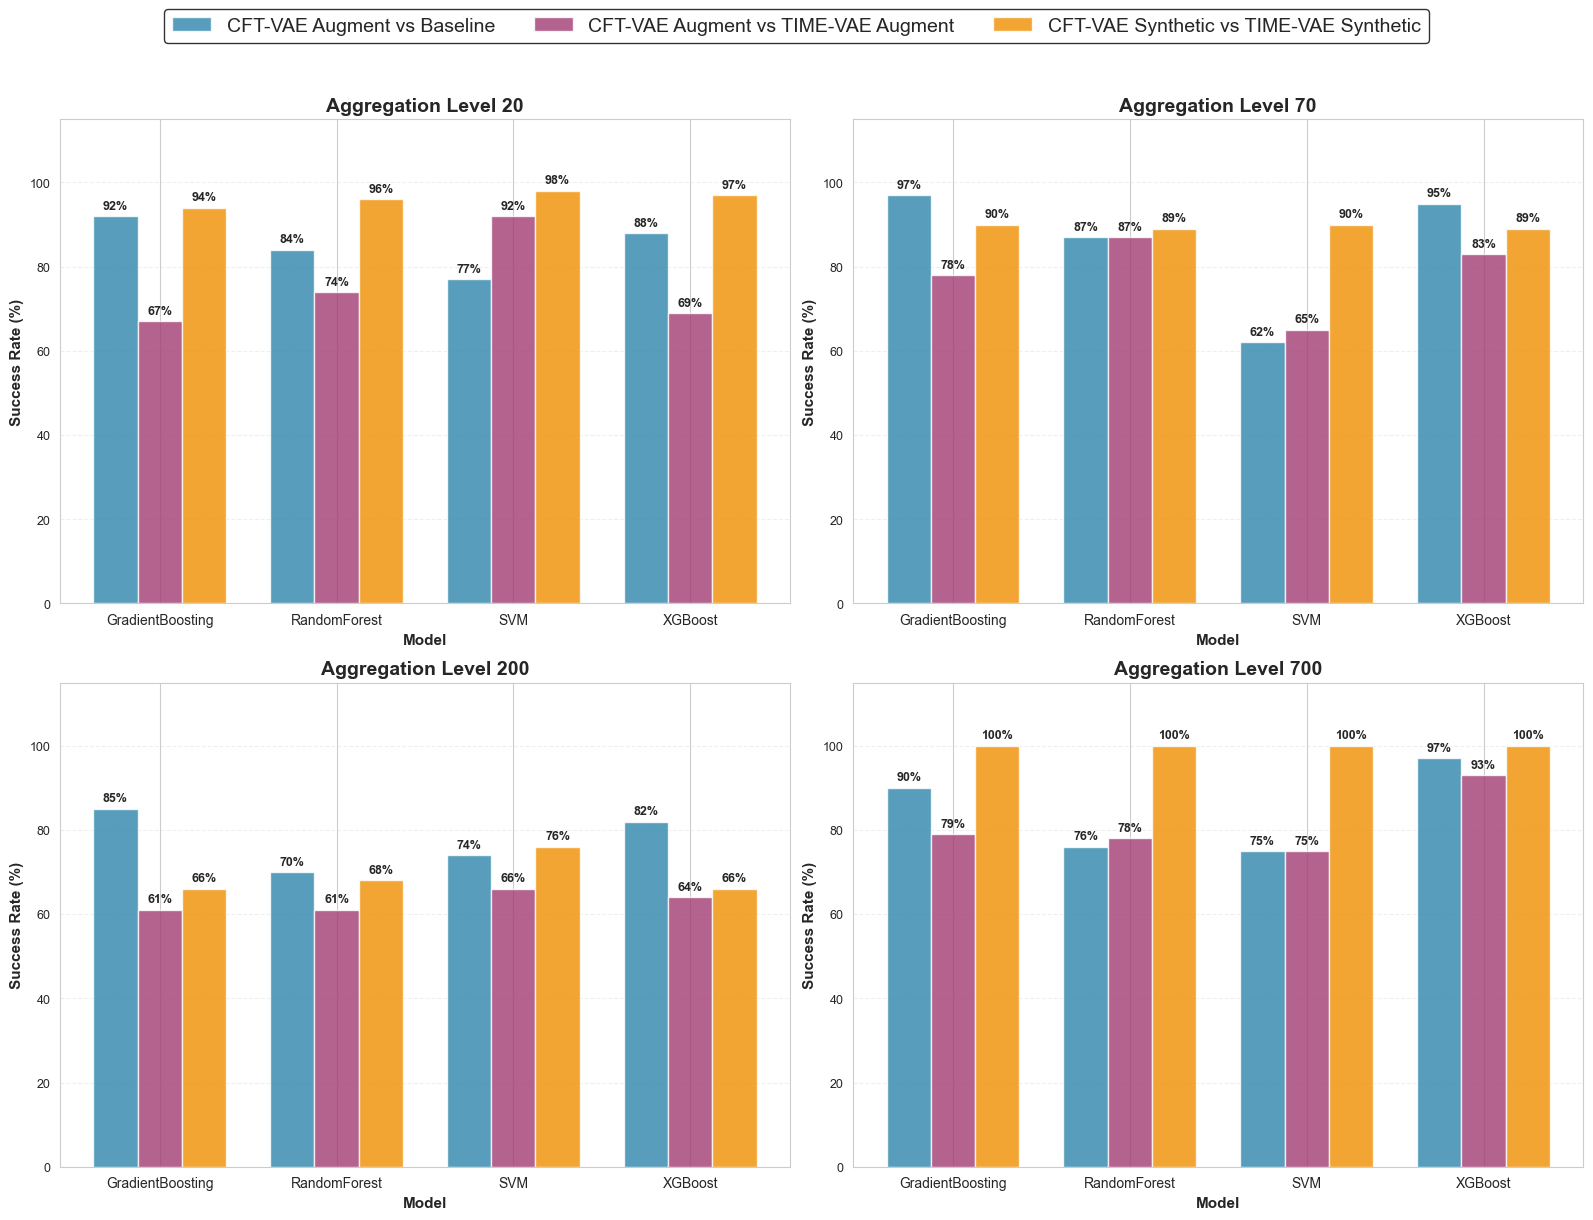

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ==============================================================================
# WR2 VISUALIZATION CONFIGURATION
# ==============================================================================
CFT_VAE_RESULTS    = r"C:\Users\bin150\OneDrive - UBC\Desktop\Publication\WR2\cft-vae\forecasting_results"
TIME_VAE_RESULTS   = r"C:\Users\bin150\OneDrive - UBC\Desktop\Publication\WR2\Timevae\original_forecasting_results"
SAVE_VIS_DIR       = r"C:\Users\bin150\OneDrive - UBC\Desktop\Publication\WR2\cft-vae\Visualization"

os.makedirs(SAVE_VIS_DIR, exist_ok=True)

LEVELS = [20, 70, 200, 700]
MODELS = ['GradientBoosting', 'RandomForest', 'SVM', 'XGBoost']
RATIO = 1.0

def calculate_success_rates():
    """Processes trial CSVs and calculates comparison percentages."""
    level_data = {}
    ratio_str = str(RATIO).replace(".", "p")

    for level in LEVELS:
        cft_path = os.path.join(CFT_VAE_RESULTS, f"results_level{level}_ratio{ratio_str}.csv")
        tvae_path = os.path.join(TIME_VAE_RESULTS, f"results_level{level}_ratio{ratio_str}.csv")

        if not os.path.exists(cft_path) or not os.path.exists(tvae_path):
            print(f"⚠️ Missing data for Level {level}")
            continue

        df_cft = pd.read_csv(cft_path)
        df_tvae = pd.read_csv(tvae_path)
        
        results = []
        for model in MODELS:
            # Filter for specific model
            c_aug = df_cft[(df_cft['model'] == model) & (df_cft['training_type'] == 'augmented')].reset_index()
            c_syn = df_cft[(df_cft['model'] == model) & (df_cft['training_type'] == 'synthetic_only')].reset_index()
            t_aug = df_tvae[(df_tvae['model'] == model) & (df_tvae['training_type'] == 'augmented')].reset_index()
            t_syn = df_tvae[(df_tvae['model'] == model) & (df_tvae['training_type'] == 'synthetic_only')].reset_index()

            # 1. CFT-VAE Augment vs Baseline
            rate1 = (c_aug['result_rmse'] < c_aug['baseline_rmse']).mean() * 100

            # 2. CFT-VAE Augment vs TIME-VAE Augment
            rate2 = (c_aug['result_rmse'] < t_aug['result_rmse']).mean() * 100

            # 3. CFT-VAE Synthetic vs TIME-VAE Synthetic
            rate3 = (c_syn['result_rmse'] < t_syn['result_rmse']).mean() * 100

            results.append({
                'model': model,
                'CFT-VAE Augment vs Baseline': rate1,
                'CFT-VAE Augment vs TIME-VAE Augment': rate2,
                'CFT-VAE Synthetic vs TIME-VAE Synthetic': rate3
            })
        
        level_data[level] = pd.DataFrame(results)
    
    return level_data

def plot_success_rates(data_by_level):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    colors = {
        'CFT-VAE Augment vs Baseline': '#2E86AB',       # Blue
        'CFT-VAE Augment vs TIME-VAE Augment': '#A23B72',   # Purple
        'CFT-VAE Synthetic vs TIME-VAE Synthetic': '#F18F01' # Orange
    }

    for idx, level in enumerate(LEVELS):
        ax = axes[idx]
        if level not in data_by_level:
            ax.text(0.5, 0.5, f'Level {level} Data Missing', ha='center', va='center')
            continue
            
        df = data_by_level[level]
        x = np.arange(len(MODELS))
        width = 0.25

        bars1 = ax.bar(x - width, df['CFT-VAE Augment vs Baseline'], width, 
                       label='CFT-VAE Augment vs Baseline', color=colors['CFT-VAE Augment vs Baseline'], alpha=0.8)
        bars2 = ax.bar(x, df['CFT-VAE Augment vs TIME-VAE Augment'], width, 
                       label='CFT-VAE Augment vs TIME-VAE Augment', color=colors['CFT-VAE Augment vs TIME-VAE Augment'], alpha=0.8)
        bars3 = ax.bar(x + width, df['CFT-VAE Synthetic vs TIME-VAE Synthetic'], width, 
                       label='CFT-VAE Synthetic vs TIME-VAE Synthetic', color=colors['CFT-VAE Synthetic vs TIME-VAE Synthetic'], alpha=0.8)

        # Formatting
        ax.set_xlabel('Model', fontsize=11, fontweight='bold')
        ax.set_ylabel('Success Rate (%)', fontsize=11, fontweight='bold')
        ax.set_title(f'Aggregation Level {level}', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(MODELS, fontsize=10)
        ax.set_ylim([0, 115]) 
        ax.grid(axis='y', alpha=0.3, linestyle='--')

        def add_labels(bars):
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                        f'{height:.0f}%', ha='center', va='bottom', 
                        fontsize=9, fontweight='bold')

        add_labels(bars1)
        add_labels(bars2)
        add_labels(bars3)

    # Shared Legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=3, fontsize=14, 
               bbox_to_anchor=(0.5, 1.02), frameon=True, edgecolor='black')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    save_path = os.path.join(SAVE_VIS_DIR, 'Figure_Success_Rates.tiff')
    plt.savefig(save_path, dpi=300, format='tiff', pil_kwargs={"compression": "tiff_lzw"}, bbox_inches='tight')
    
    print(f"\n✅ High-res Figure saved with updated labels to: {save_path}")
    plt.show()

if __name__ == "__main__":
    print("🚀 Analyzing 100 trials for reliability...")
    success_data = calculate_success_rates()
    plot_success_rates(success_data)

## RMSE EVALUATION

🚀 Starting WR2 Distributional Robustness Analysis...
Level 700 GradientBoosting: Std Reduction = 59.2%
Level 700 RandomForest: Std Reduction = 44.9%
Level 700 SVM: Std Reduction = 92.0%
Level 700 XGBoost: Std Reduction = 80.5%

✅ Distribution Plot saved to: C:\Users\bin150\OneDrive - UBC\Desktop\Publication\WR2\cft-vae\Visualization\Figure_RMSE_Distribution_4x4.tiff


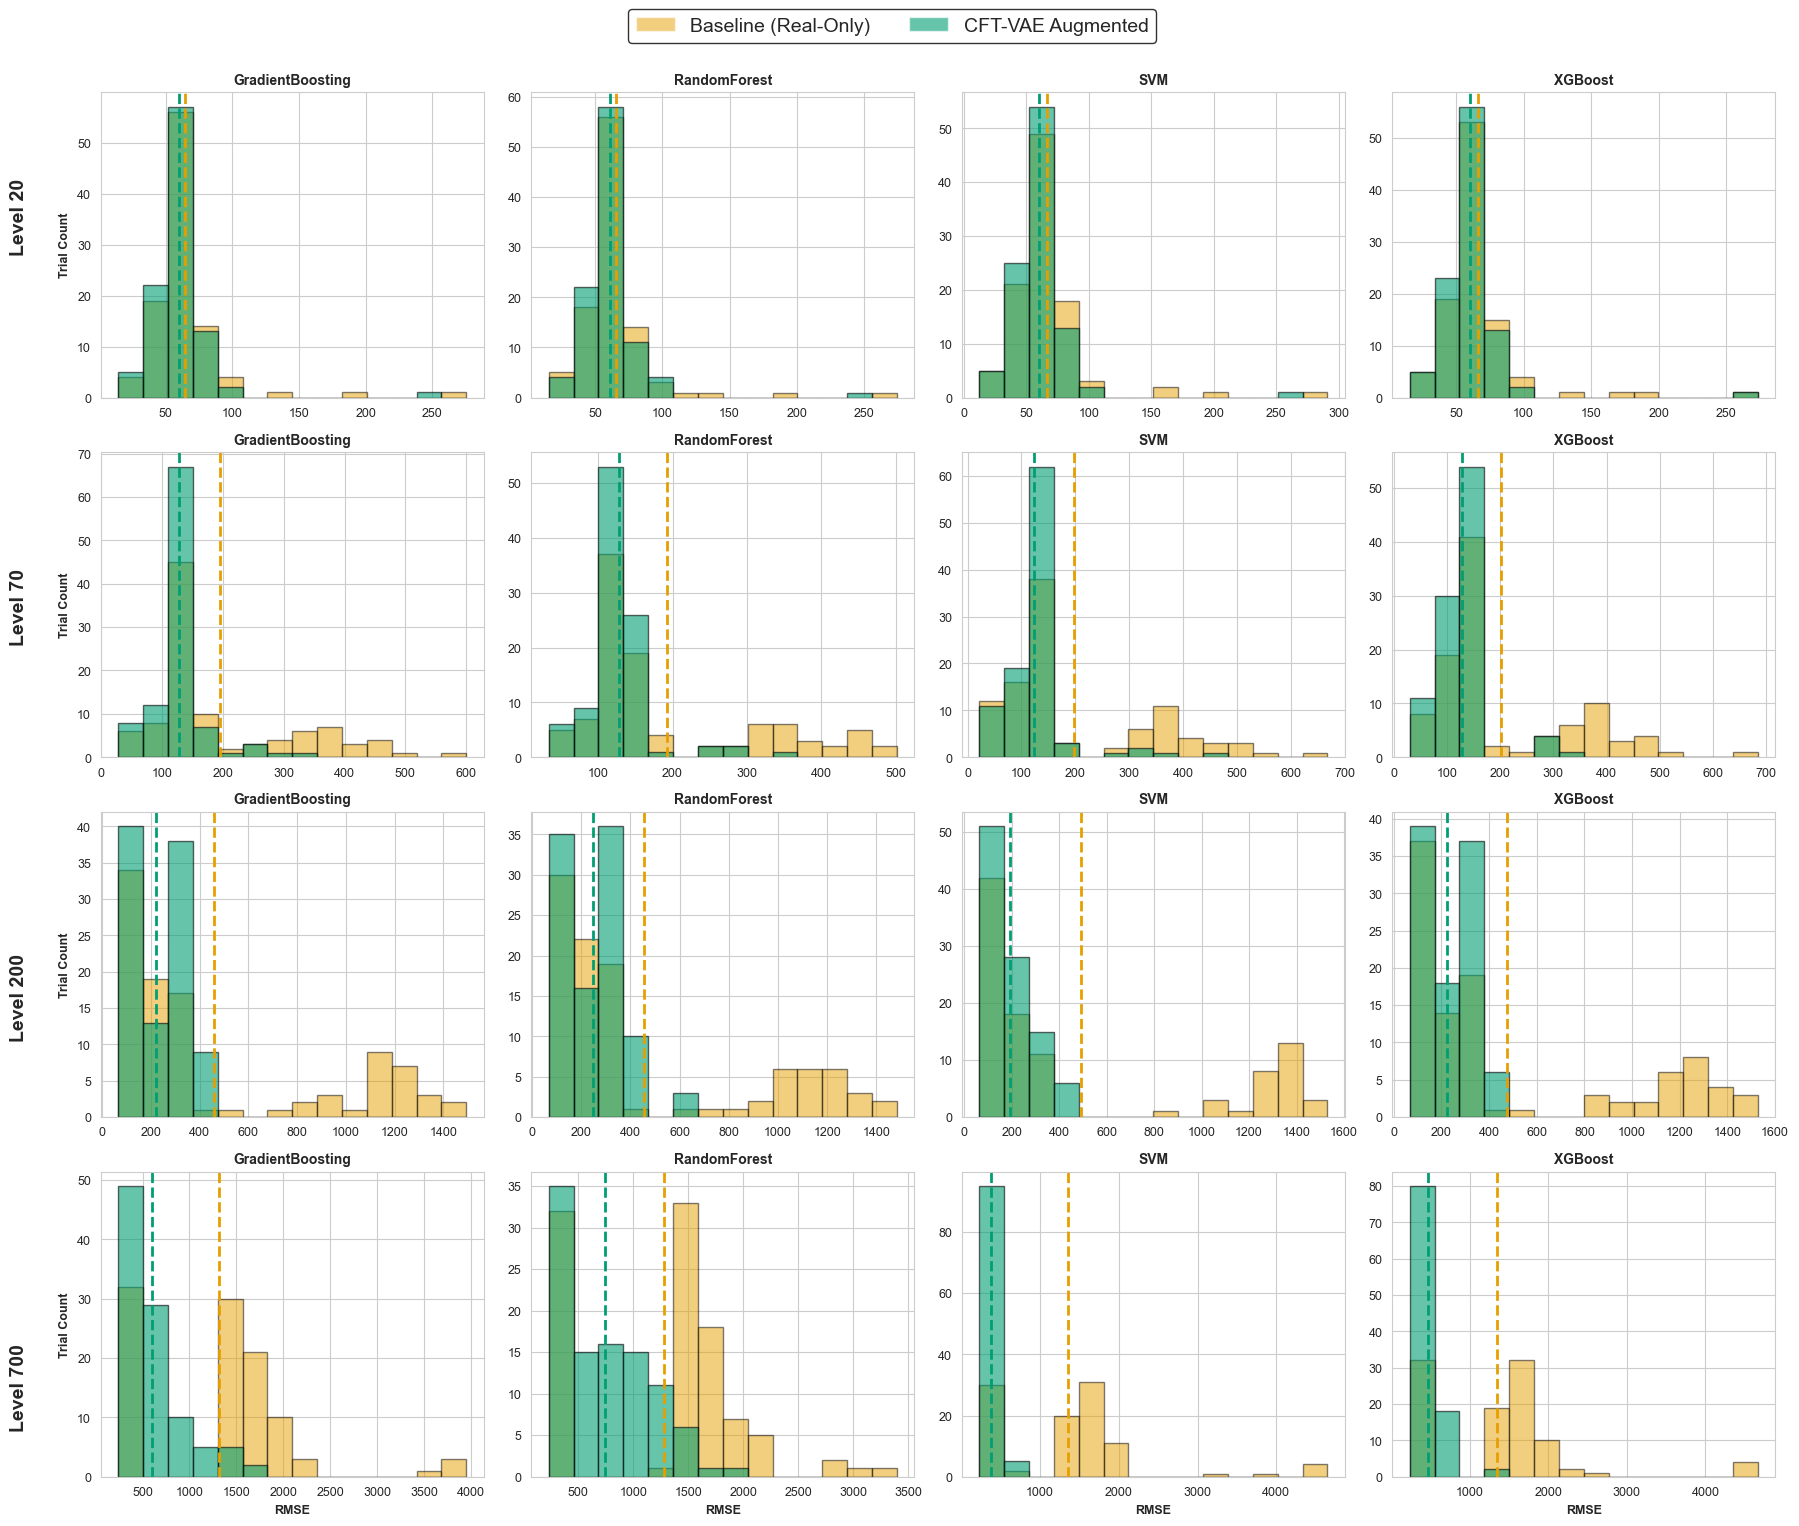

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.patches import Patch

# ==============================================================================
# WR2 CONFIGURATION
# ==============================================================================
# Input: Using the compiled CSV results we generated earlier
CFT_VAE_RESULTS    = r"C:\Users\bin150\OneDrive - UBC\Desktop\Publication\WR2\cft-vae\forecasting_results"
# Output: Visualization folder
SAVE_VIS_DIR       = r"C:\Users\bin150\OneDrive - UBC\Desktop\Publication\WR2\cft-vae\Visualization"

os.makedirs(SAVE_VIS_DIR, exist_ok=True)

LEVELS = [20, 70, 200, 700] # Updated to your specific WR2 levels
MODELS = ['GradientBoosting', 'RandomForest', 'SVM', 'XGBoost']
RATIO = 1.0

def generate_distribution_analysis():
    print(f"🚀 Starting WR2 Distributional Robustness Analysis...")
    
    sns.set_style("whitegrid")
    plt.rcParams['font.size'] = 9
    
    # Create 4x4 grid (Rows: Levels, Cols: Models)
    fig, axes = plt.subplots(4, 4, figsize=(18, 15))
    
    baseline_color = '#E69F00' # Orange-ish
    augmented_color = '#009E73' # Green-ish
    
    ratio_str = str(RATIO).replace('.', 'p')

    for level_idx, level in enumerate(LEVELS):
        csv_path = os.path.join(CFT_VAE_RESULTS, f"results_level{level}_ratio{ratio_str}.csv")
        
        if not os.path.exists(csv_path):
            print(f"⚠️ Missing Level {level} at {csv_path}")
            continue
            
        df = pd.read_csv(csv_path)
        
        for model_idx, model_name in enumerate(MODELS):
            ax = axes[level_idx, model_idx]
            
            # Filter data for this specific model
            m_df = df[df['model'] == model_name]
            
            # Extract trials for the Baseline (from augmented rows) and Augmented
            # Assuming 100 trials are present
            aug_data = m_df[m_df['training_type'] == 'augmented']
            
            b_rmse = aug_data['baseline_rmse'].values
            a_rmse = aug_data['result_rmse'].values
            
            # Calculate Statistics for the description
            b_std = np.std(b_rmse)
            a_std = np.std(a_rmse)
            var_reduction = ((b_std - a_std) / b_std * 100) if b_std > 0 else 0
            
            # Histogram plotting
            min_val = min(np.min(b_rmse), np.min(a_rmse))
            max_val = max(np.max(b_rmse), np.max(a_rmse))
            bins = np.linspace(min_val, max_val, 15)
            
            ax.hist(b_rmse, bins=bins, alpha=0.5, label='Baseline', color=baseline_color, edgecolor='black')
            ax.hist(a_rmse, bins=bins, alpha=0.6, label='CFT-VAE Aug', color=augmented_color, edgecolor='black')
            
            # Mean Lines
            ax.axvline(np.mean(b_rmse), color=baseline_color, linestyle='--', linewidth=2)
            ax.axvline(np.mean(a_rmse), color=augmented_color, linestyle='--', linewidth=2)
            
            # Subplot Labels
            if level_idx == 3: ax.set_xlabel('RMSE', fontweight='bold')
            if model_idx == 0: ax.set_ylabel('Trial Count', fontweight='bold')
            
            ax.set_title(f"{model_name}", fontsize=10, fontweight='bold')
            
            # Print variance reduction for your Section 5.2 writing
            if level == 700: # Example printout for your analysis
                 print(f"Level {level} {model_name}: Std Reduction = {var_reduction:.1f}%")

        # Row label for Levels
        fig.text(0.01, 0.875 - (level_idx * 0.26), f'Level {level}', 
                 fontsize=14, fontweight='bold', rotation=90, va='center')

    # Global Legend
    legend_elements = [
        Patch(facecolor=baseline_color, alpha=0.5, label='Baseline (Real-Only)'),
        Patch(facecolor=augmented_color, alpha=0.6, label='CFT-VAE Augmented')
    ]
    fig.legend(handles=legend_elements, loc='upper center', ncol=2, fontsize=14, 
               bbox_to_anchor=(0.5, 1.02), frameon=True, edgecolor='black')

    plt.tight_layout(rect=[0.03, 0, 1, 0.98])
    
    # Save as Journal-Quality TIFF
    save_path = os.path.join(SAVE_VIS_DIR, f"Figure_RMSE_Distribution_4x4.tiff")
    plt.savefig(save_path, dpi=300, format='tiff', pil_kwargs={"compression": "tiff_lzw"}, bbox_inches='tight')
    
    print(f"\n✅ Distribution Plot saved to: {save_path}")
    plt.show()

if __name__ == "__main__":
    generate_distribution_analysis()

## CLASSFICATION

✅ Updated WR2 Figure saved to: C:\Users\bin150\OneDrive - UBC\Desktop\Publication\WR2\cft-vae\Visualization\Figure_Hybrid_Diagnostics_Level700.tiff


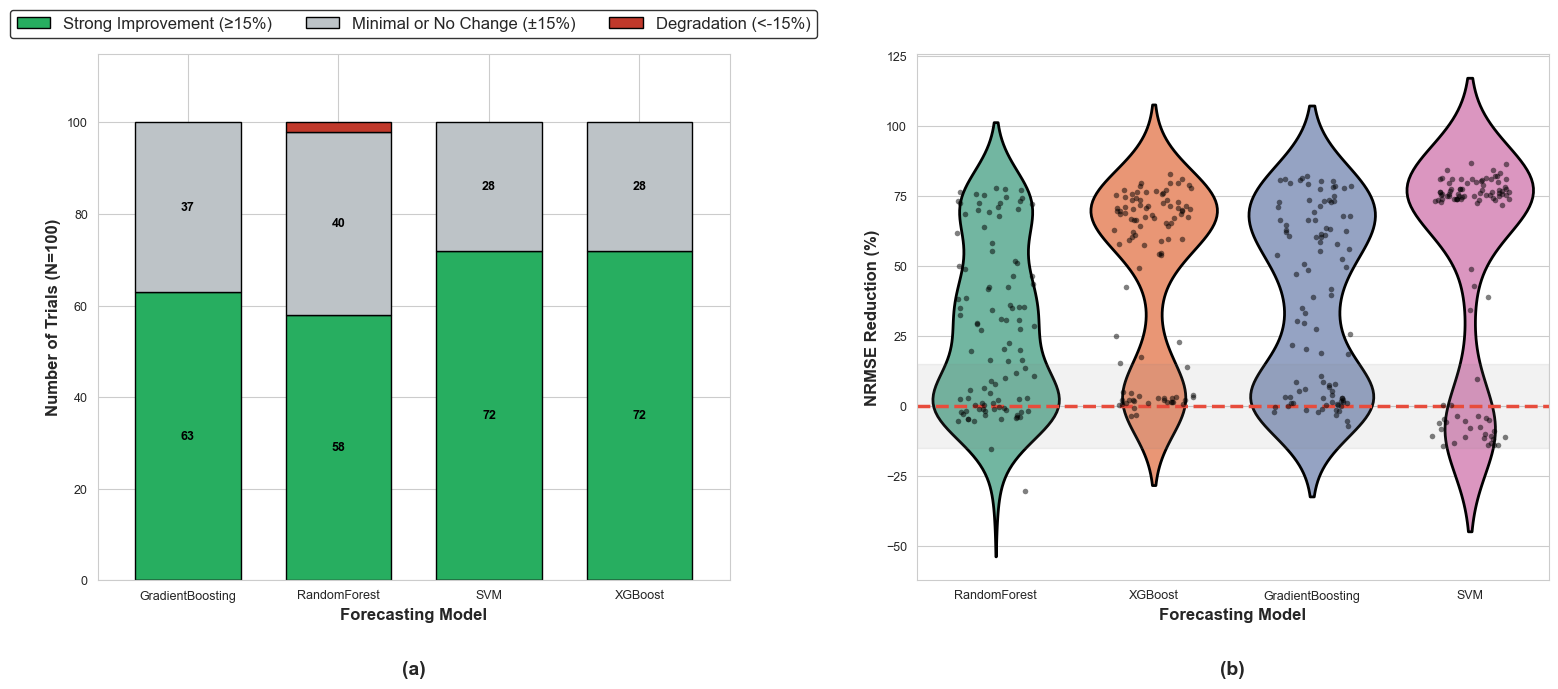

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.collections import PolyCollection

# ==============================================================================
# WR2 CONFIGURATION
# ==============================================================================
RESULTS_DIR = r"C:\Users\bin150\OneDrive - UBC\Desktop\Publication\WR2\cft-vae\forecasting_results"
SAVE_VIS_DIR = r"C:\Users\bin150\OneDrive - UBC\Desktop\Publication\WR2\cft-vae\Visualization"
REPRESENTATIVE_LEVEL = 700
RATIO = 1.0

def load_and_process_data(results_dir, level, ratio=1.0):
    ratio_str = str(ratio).replace('.', 'p')
    filename = f"results_level{level}_ratio{ratio_str}.csv"
    filepath = os.path.join(results_dir, filename)
    
    if not os.path.exists(filepath):
        print(f"Error: {filename} not found.")
        return None

    df = pd.read_csv(filepath)
    df_aug = df[df['training_type'] == 'augmented'].copy()
    
    # Calculate % Improvement: (Baseline - Augmented) / Baseline * 100
    df_aug['Improvement'] = (df_aug['baseline_rmse'] - df_aug['result_rmse']) / df_aug['baseline_rmse'] * 100
    return df_aug[['trial', 'model', 'Improvement']]

def categorize_trial(pct):
    """
    Updated Rule:
    Strong Improvement (≥15%)
    Minimal/No Change (-15% to +15%)
    Degradation (<-15%)
    """
    if pct >= 15:
        return 'Strong Improvement (≥15%)'
    elif -15 <= pct < 15:
        return 'Minimal or No Change (±15%)'
    else:
        return 'Degradation (<-15%)'

def plot_hybrid_dashboard(df, level, save_dir):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # --------------------------------------------------------
    # (a) STACKED BAR CHART
    # --------------------------------------------------------
    ax = axes[0]
    df['Category'] = df['Improvement'].apply(categorize_trial)
    counts = df.groupby(['model', 'Category']).size().unstack(fill_value=0)
    
    # Update the display order to match the new categories
    order = ['Strong Improvement (≥15%)', 'Minimal or No Change (±15%)', 'Degradation (<-15%)']
    counts = counts.reindex(columns=order, fill_value=0)
    
    # Colors: Dark Green, Gray/Light Blue (Neutral), Dark Red
    colors_bar = ['#27ae60', '#bdc3c7', '#c0392b']
    
    counts.plot(kind='bar', stacked=True, ax=ax, color=colors_bar, edgecolor='black', width=0.7)
    
    for c in ax.containers:
        # Changed color to 'black' for better legibility on gray/green
        labels = [int(v.get_height()) if v.get_height() > 5 else '' for v in c]
        ax.bar_label(c, labels=labels, label_type='center', fontweight='bold', color='black')

    ax.set_ylabel("Number of Trials (N=100)", fontsize=12, fontweight='bold')
    ax.set_xlabel("Forecasting Model", fontsize=12, fontweight='bold')
    ax.set_ylim(0, 115) 
    ax.tick_params(axis='x', rotation=0)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.10), ncol=3, frameon=True, edgecolor='black', fontsize=12)
    ax.text(0.5, -0.18, '(a)', transform=ax.transAxes, fontsize=14, fontweight='bold', ha='center')

    # --------------------------------------------------------
    # (b) VIOLIN + STRIP PLOT
    # --------------------------------------------------------
    ax = axes[1]
    sns.violinplot(data=df, x='model', y='Improvement', ax=ax, 
                   hue='model', palette="Set2", inner=None, linewidth=2.0, legend=False)
    
    for art in ax.findobj(PolyCollection):
        art.set_edgecolor('black')

    sns.stripplot(data=df, x='model', y='Improvement', ax=ax, 
                  color='black', alpha=0.5, jitter=0.25, size=4)
    
    # Red dashed line at 0% to show the neutral baseline
    ax.axhline(0, color='#e74c3c', linestyle='--', linewidth=2.5)
    
    # Adding shading for the "Minimal Change" region (-15 to +15) can be very helpful here
    ax.axhspan(-15, 15, color='gray', alpha=0.1, label='Neutral Zone')
    
    ax.set_ylabel("NRMSE Reduction (%)", fontsize=12, fontweight='bold')
    ax.set_xlabel("Forecasting Model", fontsize=12, fontweight='bold')
    ax.text(0.5, -0.18, '(b)', transform=ax.transAxes, fontsize=14, fontweight='bold', ha='center')

    plt.tight_layout()
    
    save_path = os.path.join(save_dir, f"Figure_Hybrid_Diagnostics_Level{level}.tiff")
    plt.savefig(save_path, dpi=300, format='tiff', pil_kwargs={"compression": "tiff_lzw"}, bbox_inches='tight')
    print(f"✅ Updated WR2 Figure saved to: {save_path}")
    plt.show()

if __name__ == "__main__":
    data = load_and_process_data(RESULTS_DIR, REPRESENTATIVE_LEVEL, RATIO)
    if data is not None:
        plot_hybrid_dashboard(data, REPRESENTATIVE_LEVEL, SAVE_VIS_DIR)